# TP4 y TP5 — Modelos Estacionales y de Volatilidad: Petróleo WTI

**Universidad Católica Argentina — Licenciatura en Ciencia de Datos**  
**Análisis y Predicción en Series de Tiempo**

Continuación de los TP1–TP3. Este notebook cubre:

**TP4 — Modelos Estacionales:**
1. Análisis de estacionalidad en el WTI
2. SAR, SMA, SARMA puros
3. SARIMA$(p,d,q)(P,D,Q)_s$ completo
4. Modelo REGARMA
5. Regresión estacional armónica
6. Diagnóstico y predicción de cada modelo

**TP5 — Modelos de Volatilidad:**
1. Retomada del GARCH(1,1) del TP3
2. ARCH(p)
3. GARCH(p,q)
4. EGARCH
5. TGARCH / GJR-GARCH
6. Cuadro comparativo y conclusiones

---
## 0. Configuración del Entorno

In [9]:
import os
from fredapi import Fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from arch import arch_model
from scipy import stats
import pmdarima as pm
from dotenv import load_dotenv
import os

load_dotenv()
print("Clave encontrada:", FRED_API_KEY)
FRED_API_KEY = os.getenv('FRED_API_KEY')
fred = Fred(api_key=FRED_API_KEY)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Librerías importadas correctamente.')

Clave encontrada: None


ValueError: You need to set a valid API key. You can set it in 3 ways:
pass the string with api_key, or set api_key_file to a
file with the api key in the first line, or set the
environment variable 'FRED_API_KEY' to the value of your
api key. You can sign up for a free api key on the Fred
website at http://research.stlouisfed.org/fred2/

In [ ]:
warnings.filterwarnings('ignore')

---
## 1. Carga y Preprocesamiento (idéntico a TP1–TP3)

In [ ]:
FRED_API_KEY = userdata.get('FRED_API_KEY')
fred = Fred(api_key=FRED_API_KEY)

wti_raw = fred.get_series('DCOILWTICO', observation_start='1986-01-01')
df = pd.DataFrame(wti_raw, columns=['Close'])
df['Close'] = df['Close'].ffill().bfill()
df.loc['2020-04-20', 'Close'] = np.nan
df['Close'] = df['Close'].interpolate(method='linear')

# Serie de retornos logarítmicos (usada en TP2 y TP3)
serie = np.log(df['Close']).diff().dropna()
serie.name = 'log_ret_WTI'

# Precio original (para SARIMA sobre precio)
precio = df['Close']

print(f'Observaciones: {len(serie)}')
print(f'Período      : {serie.index[0].date()} → {serie.index[-1].date()}')

Observaciones: 10547
Período      : 1986-01-03 → 2026-06-08


---
# TP4 — MODELOS ESTACIONALES

---
## 2. ¿Tiene el WTI componente estacional?

### 2.1 Justificación del contexto

Los **retornos logarítmicos** del WTI (serie de trabajo del TP2/TP3) son estacionarios
y con escasa memoria lineal — como verificamos con KPSS. Para buscar estacionalidad
tiene más sentido trabajar sobre el **precio mensual**, que es donde típicamente
emergen patrones estacionales en commodities energéticos (demanda invernal,
ciclos de producción OPEC, etc.).

Remuestreamos el precio a frecuencia mensual y analizamos si hay estacionalidad.

Precio mensual: 486 obs. (1986-01-01 → 2026-06-01)


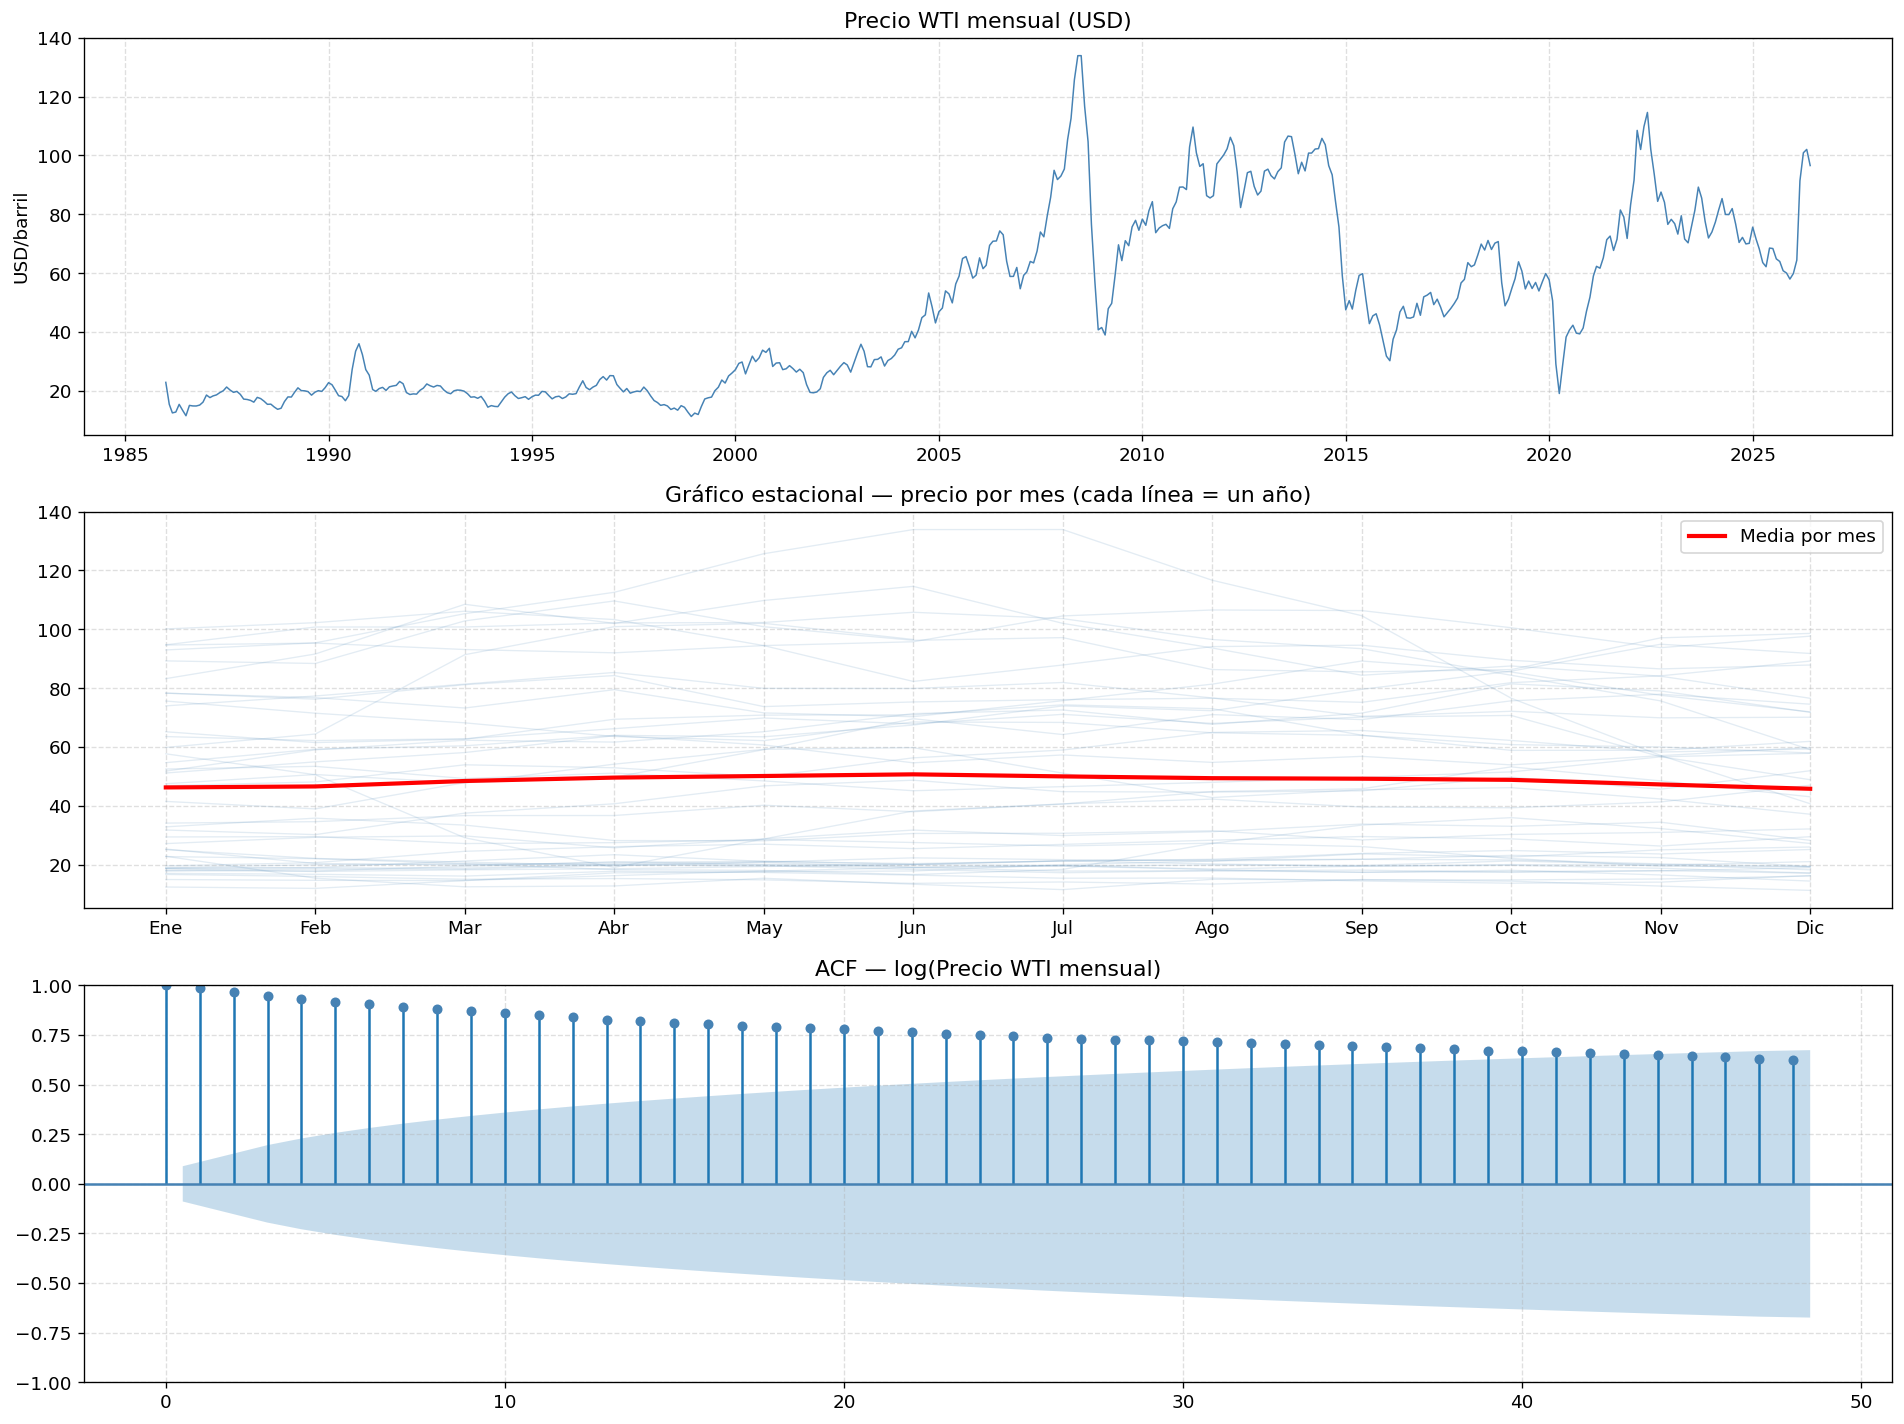

In [ ]:
# Precio mensual (media mensual)
precio_mensual = precio.resample('MS').mean().dropna()
log_precio_mensual = np.log(precio_mensual)

print(f'Precio mensual: {len(precio_mensual)} obs. '
      f'({precio_mensual.index[0].date()} → {precio_mensual.index[-1].date()})')

# --- Gráfico exploratorio ---
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(precio_mensual, color='steelblue', linewidth=0.9)
axes[0].set_title('Precio WTI mensual (USD)')
axes[0].set_ylabel('USD/barril')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Gráfico estacional por mes
precio_mensual_df = precio_mensual.to_frame('precio')
precio_mensual_df['mes'] = precio_mensual_df.index.month
precio_mensual_df['año'] = precio_mensual_df.index.year
for año in precio_mensual_df['año'].unique():
    subset = precio_mensual_df[precio_mensual_df['año'] == año]
    axes[1].plot(subset['mes'], subset['precio'],
                 color='steelblue', alpha=0.15, linewidth=0.8)
media_mes = precio_mensual_df.groupby('mes')['precio'].mean()
axes[1].plot(media_mes.index, media_mes.values,
             color='red', linewidth=2.5, label='Media por mes')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                          'Jul','Ago','Sep','Oct','Nov','Dic'])
axes[1].set_title('Gráfico estacional — precio por mes (cada línea = un año)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plot_acf(log_precio_mensual, lags=48, ax=axes[2],
         title='ACF — log(Precio WTI mensual)', alpha=0.05,
         color='steelblue')
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

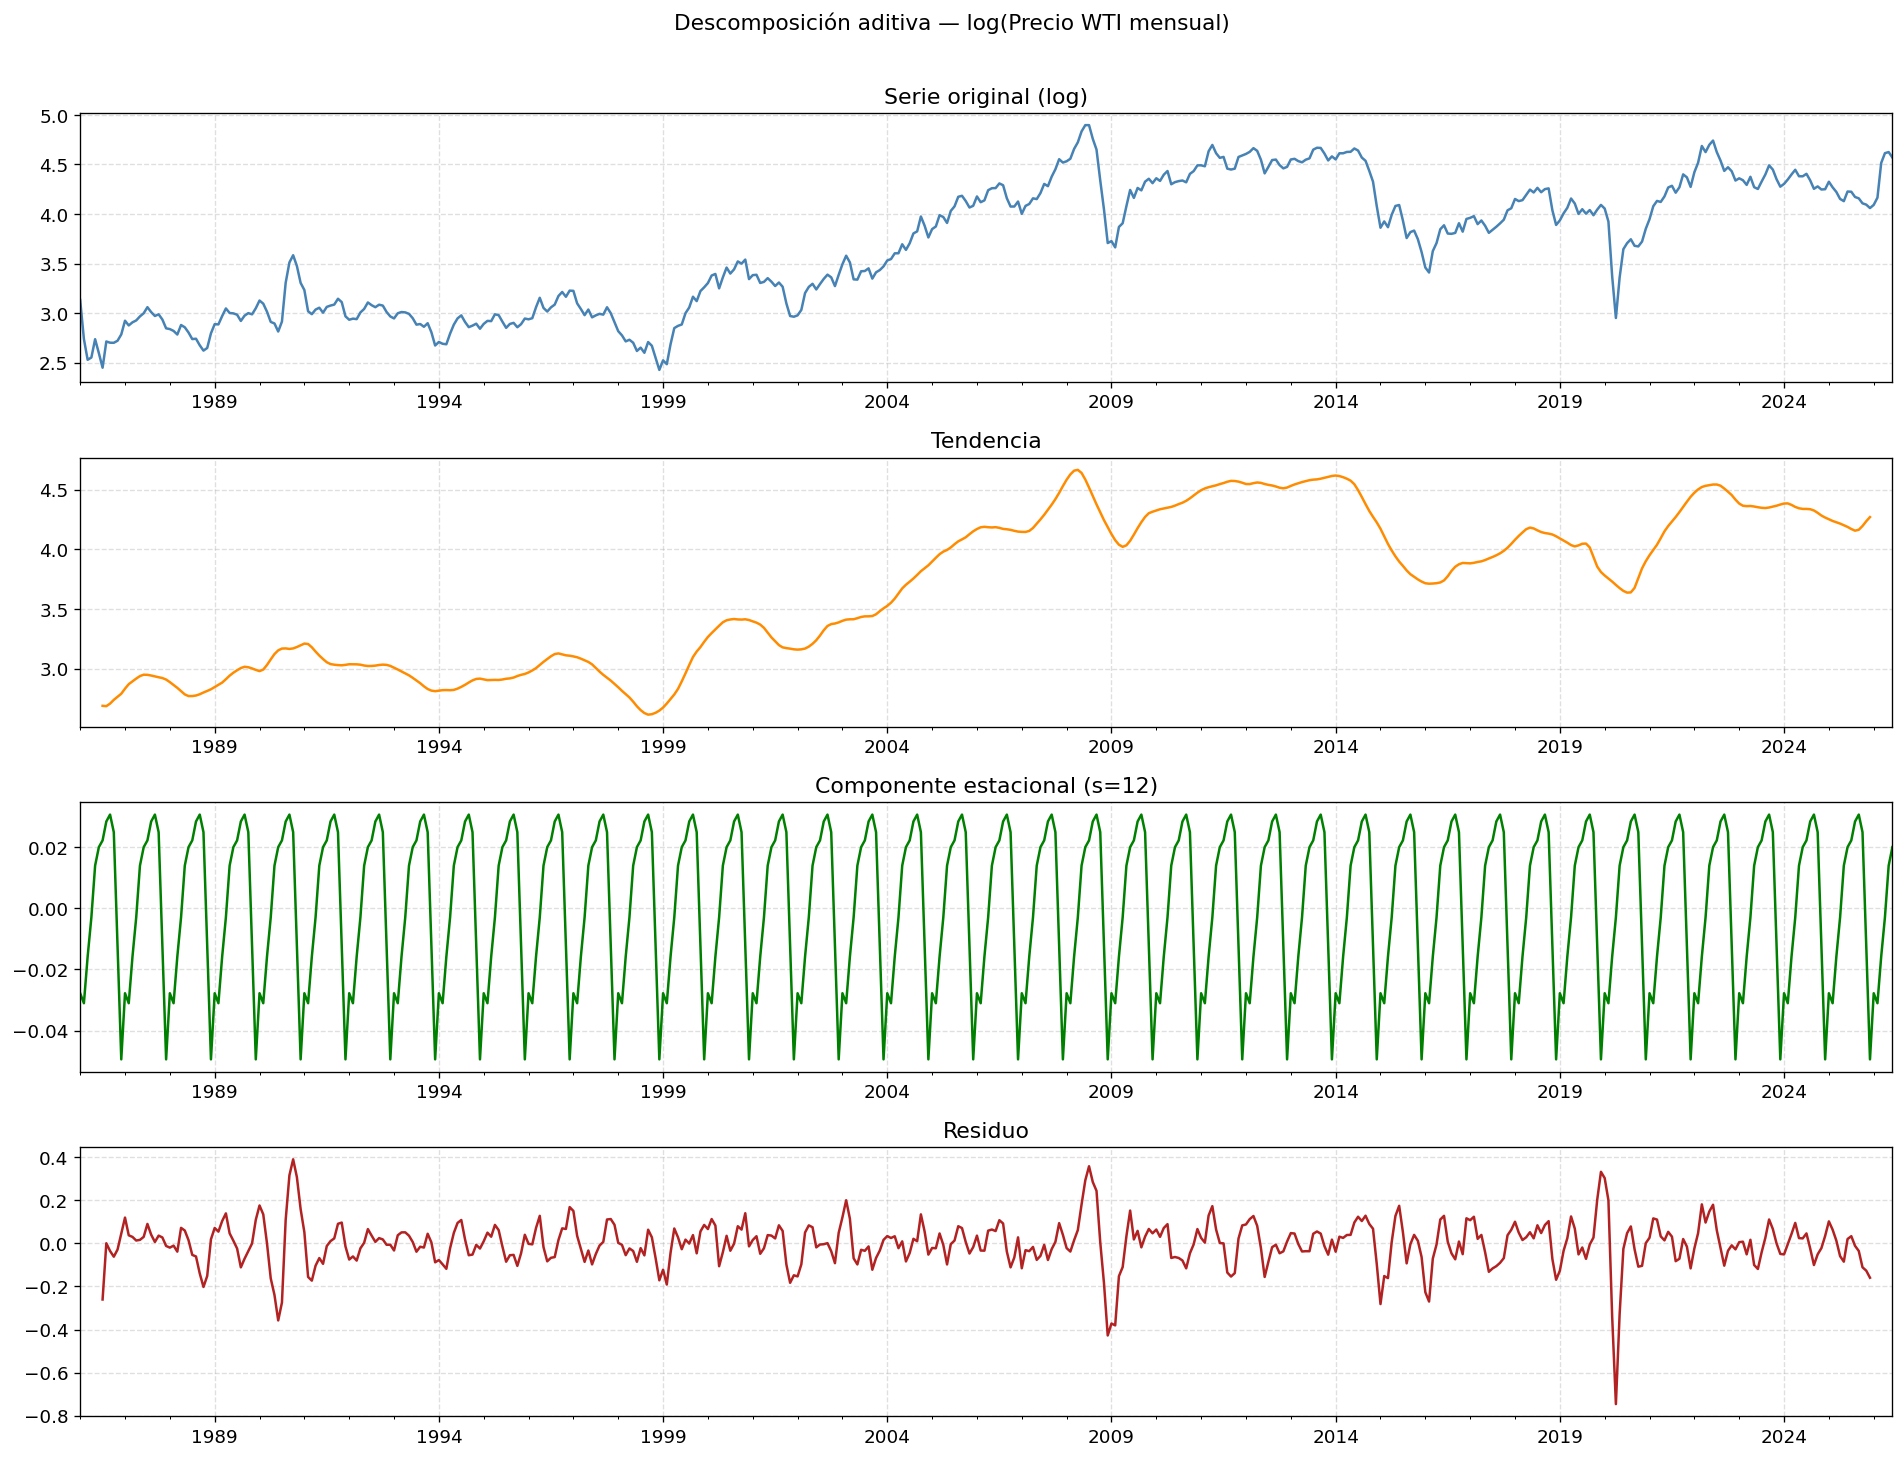

In [ ]:
# --- Descomposición estacional ---
descomp = seasonal_decompose(log_precio_mensual, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
descomp.observed.plot(ax=axes[0], title='Serie original (log)', color='steelblue')
descomp.trend.plot(ax=axes[1], title='Tendencia', color='darkorange')
descomp.seasonal.plot(ax=axes[2], title='Componente estacional (s=12)', color='green')
descomp.resid.plot(ax=axes[3], title='Residuo', color='firebrick')
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.4)
plt.suptitle('Descomposición aditiva — log(Precio WTI mensual)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# --- Test KPSS sobre precio mensual y diferenciado ---
def kpss_test(serie, label):
    stat, pval, lags, crit = kpss(serie.dropna(), regression='c', nlags='auto')
    decision = 'No estacionaria' if pval < 0.05 else 'Estacionaria'
    print(f'{label:45s} stat={stat:.4f}  p={pval:.4f}  → {decision}')

print('─── Test KPSS ───')
kpss_test(log_precio_mensual,                        'log(Precio mensual)')
kpss_test(log_precio_mensual.diff(1).dropna(),       'Δ log(Precio mensual)  d=1')
kpss_test(log_precio_mensual.diff(12).dropna(),      'Δ₁₂ log(Precio mensual) D=1')
kpss_test(log_precio_mensual.diff(12).diff(1).dropna(), 'Δ Δ₁₂ log(Precio mensual) d=1,D=1')

─── Test KPSS ───
log(Precio mensual)                           stat=2.9436  p=0.0100  → No estacionaria
Δ log(Precio mensual)  d=1                    stat=0.0342  p=0.1000  → Estacionaria
Δ₁₂ log(Precio mensual) D=1                   stat=0.0701  p=0.1000  → Estacionaria
Δ Δ₁₂ log(Precio mensual) d=1,D=1             stat=0.0119  p=0.1000  → Estacionaria


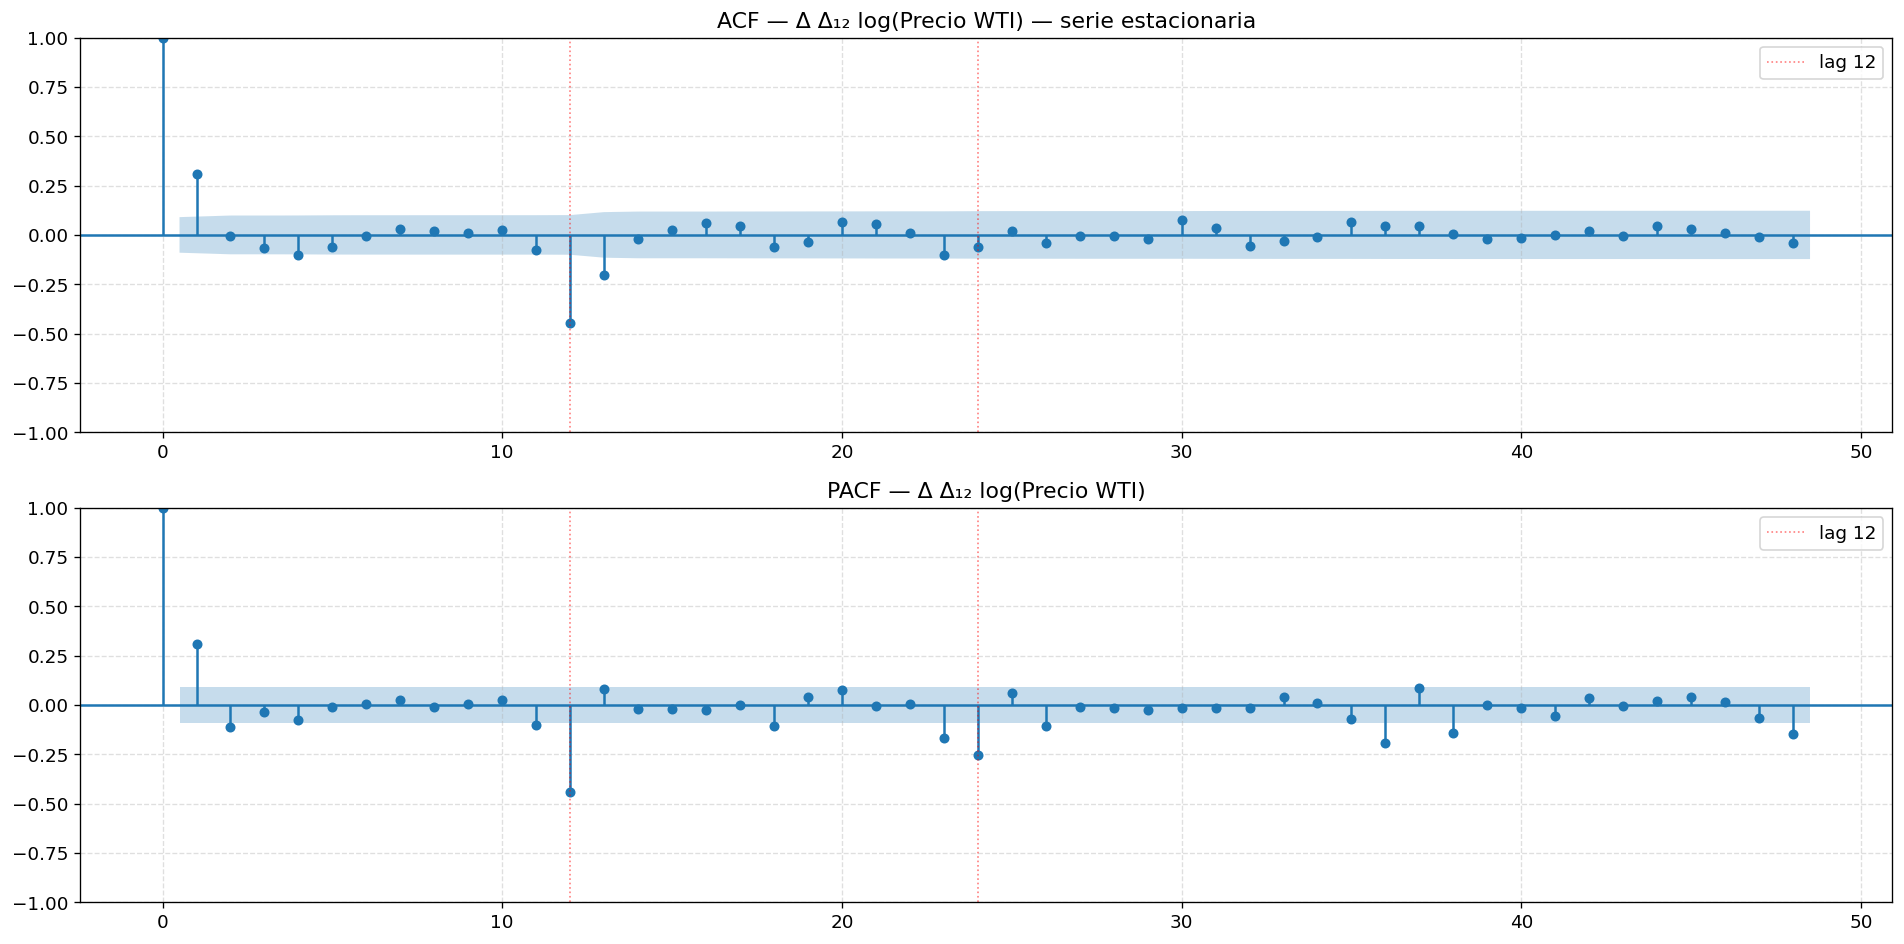

In [ ]:
# --- ACF y PACF de la serie diferenciada (d=1, D=1, s=12) ---
serie_diff = log_precio_mensual.diff(12).diff(1).dropna()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
plot_acf(serie_diff, lags=48, ax=axes[0],
         title='ACF — Δ Δ₁₂ log(Precio WTI) — serie estacionaria', alpha=0.05)
plot_pacf(serie_diff, lags=48, method='ywm', ax=axes[1],
          title='PACF — Δ Δ₁₂ log(Precio WTI)', alpha=0.05)
for ax in axes:
    ax.axvline(12, color='red', linestyle=':', linewidth=1, alpha=0.5, label='lag 12')
    ax.axvline(24, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()
plt.tight_layout()
plt.show()

# Observación del gráfico ACF/PACF:
Componente ordinaria: ACF y PACF se cortan después del lag 1 → compatible con MA(1), AR(1) o ARMA(1,1).

Componente estacional: ACF presenta pico significativo en lag 12 y se corta;

PACF decrece en lags estacionales
                     → indicativo de SMA(1)₁₂ según tabla del apunte.
                     
Candidato principal: SARIMA(0,1,1)(0,1,1)₁₂ — se confirma con criterios de información.

---
## 3. Modelos SAR, SMA y SARMA Puros

Según el apunte, si $d=D=0$ y $p=q=0$, el modelo SARIMA se reduce a:
$$\Phi(B^s) X_t = \Theta(B^s)\varepsilon_t \quad \text{SARMA}(P,Q)_s \text{ puro}$$

Se ajustan sobre la **serie diferenciada estacionaria** con $s=12$.

In [ ]:
# Serie sobre la que ajustamos modelos estacionales puros
# Usamos log_precio_mensual con d=1, D=1, s=12 dentro del modelo
S = 12
modelos_est_puros = {}

# --- SAR(1)_12 puro ---
try:
    m_sar = SARIMAX(log_precio_mensual,
                    order=(0,1,0),
                    seasonal_order=(1,1,0,S)).fit(disp=False)
    modelos_est_puros['SAR(1)₁₂'] = m_sar
    print('SAR(1)₁₂ ajustado.')
except Exception as e:
    print(f'SAR: {e}')

# --- SMA(1)_12 puro ---
try:
    m_sma = SARIMAX(log_precio_mensual,
                    order=(0,1,0),
                    seasonal_order=(0,1,1,S)).fit(disp=False)
    modelos_est_puros['SMA(1)₁₂'] = m_sma
    print('SMA(1)₁₂ ajustado.')
except Exception as e:
    print(f'SMA: {e}')

# --- SARMA(1,1)_12 puro ---
try:
    m_sarma = SARIMAX(log_precio_mensual,
                      order=(0,1,0),
                      seasonal_order=(1,1,1,S)).fit(disp=False)
    modelos_est_puros['SARMA(1,1)₁₂'] = m_sarma
    print('SARMA(1,1)₁₂ ajustado.')
except Exception as e:
    print(f'SARMA: {e}')

# --- Cuadro comparativo ---
rows = []
for nombre, m in modelos_est_puros.items():
    n = len(log_precio_mensual)
    k = len(m.params)
    aicc = m.aic + (2*k*(k+1))/(n-k-1)
    hqic = -2*m.llf + 2*k*np.log(np.log(n))
    rows.append({'Modelo': nombre,
                 'LogLik': round(m.llf, 2),
                 'AIC': round(m.aic, 2),
                 'AICc': round(aicc, 2),
                 'BIC': round(m.bic, 2),
                 'HQIC': round(hqic, 2)})

df_puros = pd.DataFrame(rows).set_index('Modelo')
print('\n─── Criterios de información — Modelos estacionales puros ───')
display(df_puros)

SAR(1)₁₂ ajustado.
SMA(1)₁₂ ajustado.
SARMA(1,1)₁₂ ajustado.

─── Criterios de información — Modelos estacionales puros ───


,LogLik,AIC,AICc,BIC,HQIC
Modelo,,,,,
SAR(1)₁₂,343.30,-682.59,-682.57,-674.27,-679.30
SMA(1)₁₂,429.38,-854.77,-854.75,-846.45,-851.48
"SARMA(1,1)₁₂",429.86,-853.72,-853.67,-841.24,-848.78


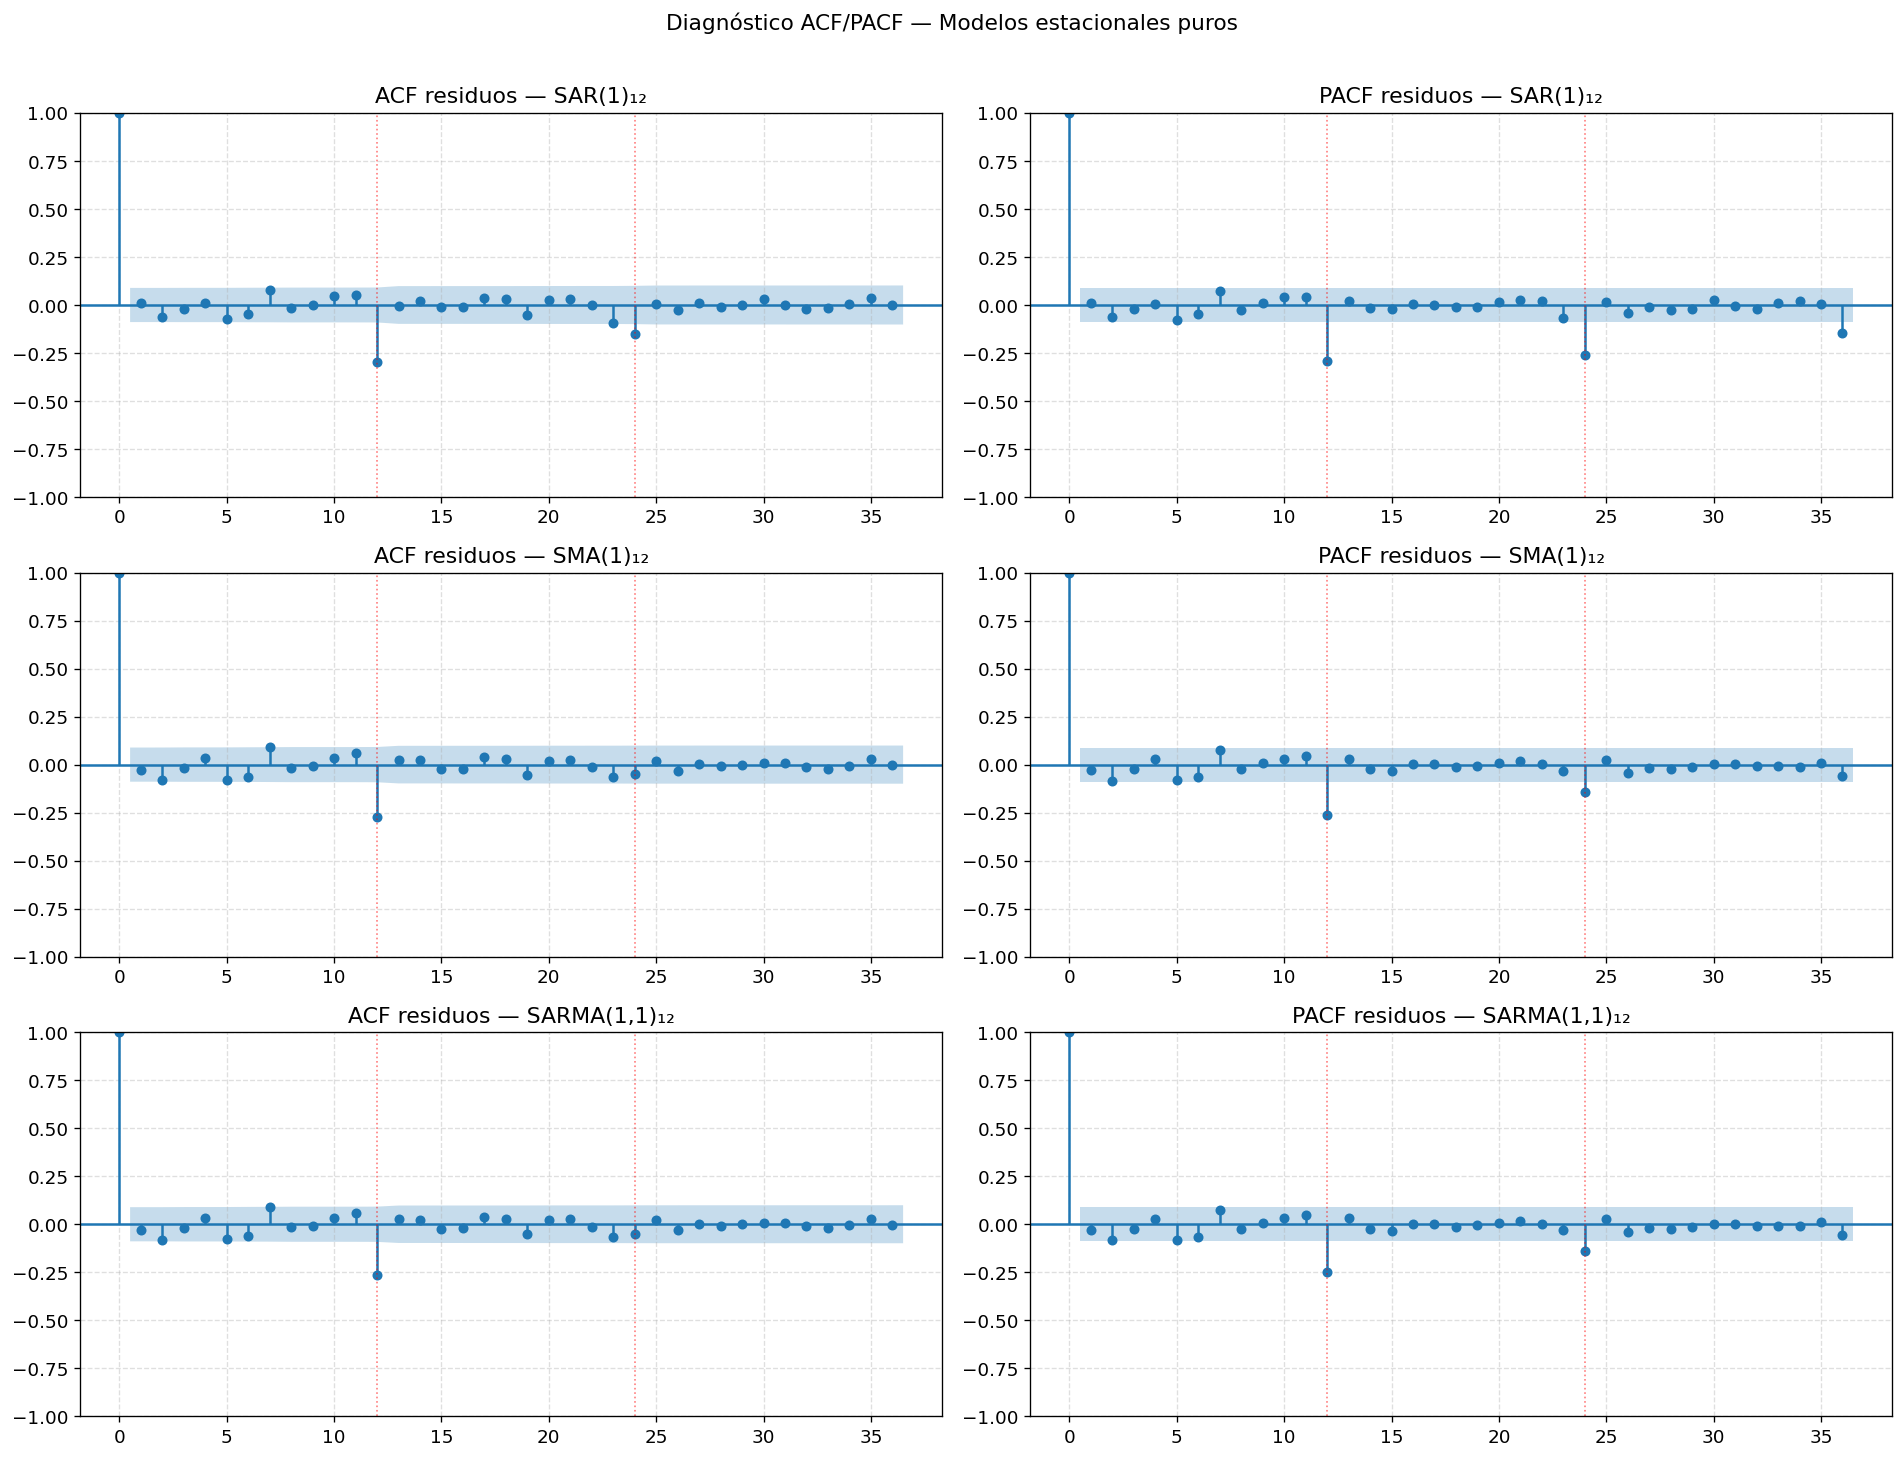

In [ ]:
# --- Propiedades ACF/PACF teóricas (verificación visual) ---
# Según el apunte:
#   SAR(P)s  → ACF decrece en lags ks; PACF se corta en lag Ps
#   SMA(Q)s  → ACF se corta en lag Qs; PACF decrece en lags ks
#   SARMA    → ambas decrecen en lags ks

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
modelos_lista = list(modelos_est_puros.items())

for i, (nombre, m) in enumerate(modelos_lista):
    resid = m.resid.dropna()
    plot_acf(resid, lags=36, ax=axes[i,0],
             title=f'ACF residuos — {nombre}', alpha=0.05)
    plot_pacf(resid, lags=36, method='ywm', ax=axes[i,1],
              title=f'PACF residuos — {nombre}', alpha=0.05)
    for ax in axes[i]:
        ax.axvline(12, color='red', linestyle=':', linewidth=1, alpha=0.5)
        ax.axvline(24, color='red', linestyle=':', linewidth=1, alpha=0.5)
        ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Diagnóstico ACF/PACF — Modelos estacionales puros', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

SAR(1)₁₂ y SMA(1)₁₂: residuos con pico significativo en lag 12 y 24

   → no capturan la estructura estacional. Modelos insuficientes.

 SARMA(1,1)₁₂: mejor de los tres, pico en lag 12 reducido pero aún marginalmente significativo → necesita componente ordinaria.

   → Los modelos estacionales puros no son adecuados para el WTI mensual.
   
   Se procede con SARIMA completo que incluye parte ordinaria (p,q).

---
## 4. SARIMA$(p,d,q)(P,D,Q)_{12}$ Completo

El modelo completo según el apunte:
$$\varphi(B)\Phi(B^s)(1-B)^d(1-B^s)^D X_t = \theta(B)\Theta(B^s)\varepsilon_t$$

Se ajustan
manualmente los candidatos más prometedores.

In [ ]:
# --- Ajuste manual de candidatos SARIMA ---
# Basado en la inspección de ACF/PACF y el resultado de auto_arima

candidatos_sarima = [
    {'orden': (1,1,1), 'sorden': (1,1,1,12), 'label': 'SARIMA(1,1,1)(1,1,1)₁₂'},
    {'orden': (0,1,1), 'sorden': (0,1,1,12), 'label': 'SARIMA(0,1,1)(0,1,1)₁₂'},
    {'orden': (1,1,0), 'sorden': (1,1,0,12), 'label': 'SARIMA(1,1,0)(1,1,0)₁₂'},
    {'orden': (0,1,1), 'sorden': (1,1,1,12), 'label': 'SARIMA(0,1,1)(1,1,1)₁₂'},
    {'orden': (1,1,1), 'sorden': (0,1,1,12), 'label': 'SARIMA(1,1,1)(0,1,1)₁₂'},
]

modelos_sarima = {}
rows_sarima = []

for c in candidatos_sarima:
    try:
        m = SARIMAX(log_precio_mensual,
                    order=c['orden'],
                    seasonal_order=c['sorden']).fit(disp=False)
        modelos_sarima[c['label']] = m
        n = len(log_precio_mensual)
        k = len(m.params)
        aicc = m.aic + (2*k*(k+1))/(n-k-1)
        hqic = -2*m.llf + 2*k*np.log(np.log(n))
        rows_sarima.append({
            'Modelo': c['label'],
            'LogLik': round(m.llf, 2),
            'AIC': round(m.aic, 2),
            'AICc': round(aicc, 2),
            'BIC': round(m.bic, 2),
            'HQIC': round(hqic, 2)
        })
        print(f'{c["label"]} ajustado.')
    except Exception as e:
        print(f'{c["label"]}: {e}')

df_sarima = pd.DataFrame(rows_sarima).set_index('Modelo').sort_values('BIC')
print('\n─── Cuadro comparativo — Modelos SARIMA ───')
display(df_sarima)

BEST_SARIMA_LABEL = df_sarima.index[0]
modelo_sarima_opt = modelos_sarima[BEST_SARIMA_LABEL]
print(f'\n→ Modelo SARIMA óptimo (menor BIC): {BEST_SARIMA_LABEL}')

SARIMA(1,1,1)(1,1,1)₁₂ ajustado.
SARIMA(0,1,1)(0,1,1)₁₂ ajustado.
SARIMA(1,1,0)(1,1,0)₁₂ ajustado.
SARIMA(0,1,1)(1,1,1)₁₂ ajustado.
SARIMA(1,1,1)(0,1,1)₁₂ ajustado.

─── Cuadro comparativo — Modelos SARIMA ───


,LogLik,AIC,AICc,BIC,HQIC
Modelo,,,,,
"SARIMA(0,1,1)(0,1,1)₁₂",453.58,-901.16,-901.11,-888.69,-896.23
"SARIMA(0,1,1)(1,1,1)₁₂",453.85,-899.70,-899.62,-883.06,-893.12
"SARIMA(1,1,1)(0,1,1)₁₂",453.59,-899.19,-899.10,-882.55,-892.61
"SARIMA(1,1,1)(1,1,1)₁₂",453.85,-897.70,-897.57,-876.90,-889.48
"SARIMA(1,1,0)(1,1,0)₁₂",367.66,-729.33,-729.28,-716.85,-724.39



→ Modelo SARIMA óptimo (menor BIC): SARIMA(0,1,1)(0,1,1)₁₂


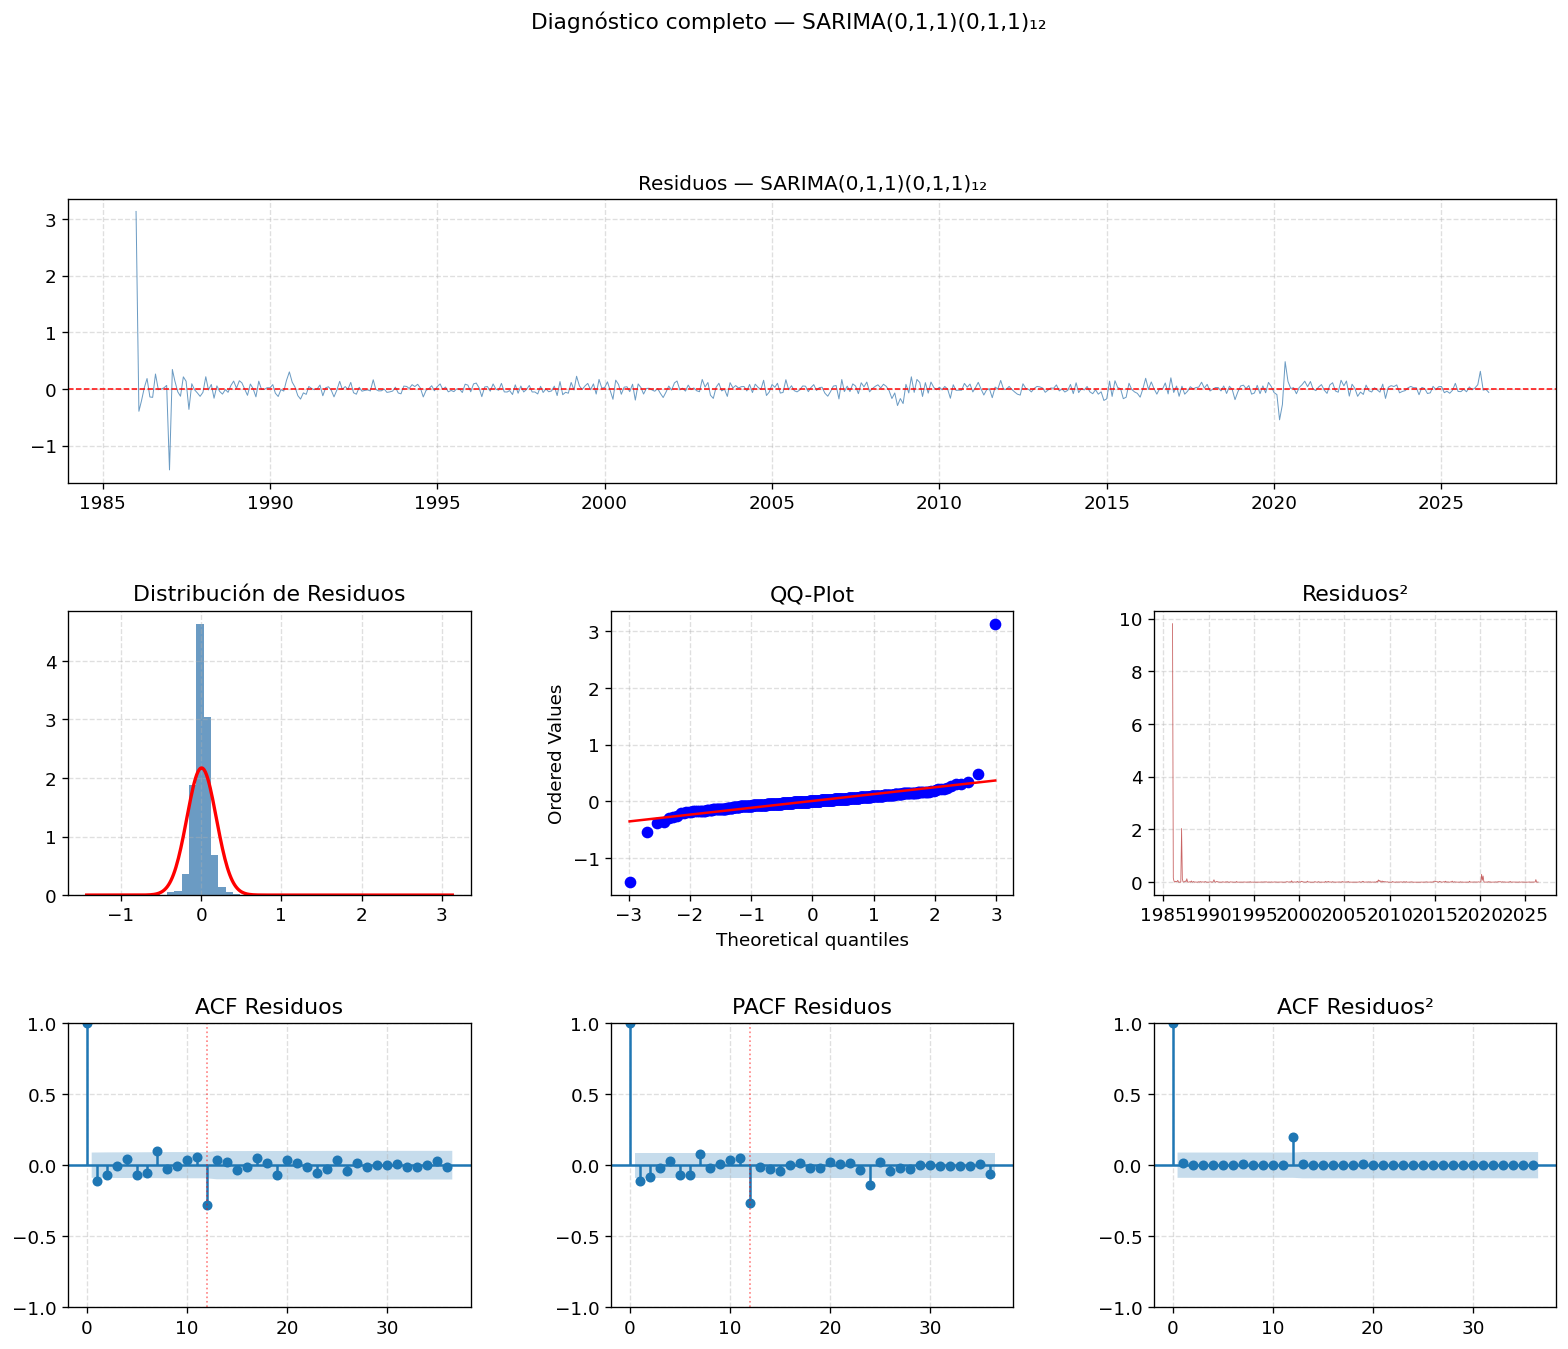

─── Tests de diagnóstico ───
  Ljung-Box lag=12: Q=  61.167  p=0.0000  ❌
  Ljung-Box lag=24: Q=  69.492  p=0.0000  ❌
  Ljung-Box lag=36: Q=  71.943  p=0.0003  ❌
  Jarque-Bera: JB=655171.01  p=0.000000


In [ ]:
# --- Diagnóstico completo del SARIMA óptimo ---

resid_sarima = modelo_sarima_opt.resid.dropna()

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(gs[0, :])
ax0.plot(resid_sarima, color='steelblue', linewidth=0.6, alpha=0.8)
ax0.axhline(0, color='red', linestyle='--', linewidth=0.9)
ax0.set_title(f'Residuos — {BEST_SARIMA_LABEL}', fontsize=12)
ax0.grid(True, linestyle='--', alpha=0.4)

ax1 = fig.add_subplot(gs[1, 0])
ax1.hist(resid_sarima, bins=50, color='steelblue', density=True, alpha=0.8)
xr = np.linspace(resid_sarima.min(), resid_sarima.max(), 300)
ax1.plot(xr, stats.norm.pdf(xr, resid_sarima.mean(), resid_sarima.std()), 'r-', lw=2)
ax1.set_title('Distribución de Residuos')
ax1.grid(True, linestyle='--', alpha=0.4)

ax2 = fig.add_subplot(gs[1, 1])
stats.probplot(resid_sarima, dist='norm', plot=ax2)
ax2.set_title('QQ-Plot')
ax2.grid(True, linestyle='--', alpha=0.4)

ax3 = fig.add_subplot(gs[1, 2])
ax3.plot(resid_sarima**2, color='firebrick', linewidth=0.5, alpha=0.7)
ax3.set_title('Residuos²')
ax3.grid(True, linestyle='--', alpha=0.4)

ax4 = fig.add_subplot(gs[2, 0])
plot_acf(resid_sarima, lags=36, ax=ax4, title='ACF Residuos', alpha=0.05)
ax4.axvline(12, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax4.grid(True, linestyle='--', alpha=0.4)

ax5 = fig.add_subplot(gs[2, 1])
plot_pacf(resid_sarima, lags=36, method='ywm', ax=ax5, title='PACF Residuos', alpha=0.05)
ax5.axvline(12, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax5.grid(True, linestyle='--', alpha=0.4)

ax6 = fig.add_subplot(gs[2, 2])
plot_acf(resid_sarima**2, lags=36, ax=ax6, title='ACF Residuos²', alpha=0.05)
ax6.grid(True, linestyle='--', alpha=0.4)

fig.suptitle(f'Diagnóstico completo — {BEST_SARIMA_LABEL}', fontsize=13, y=1.01)
plt.show()

# Tests
print('─── Tests de diagnóstico ───')
lb = acorr_ljungbox(resid_sarima, lags=[12, 24, 36], return_df=True)
for lag in [12, 24, 36]:
    r = lb.loc[lag]
    sig = '❌' if r['lb_pvalue'] < 0.05 else '✅'
    print(f'  Ljung-Box lag={lag:2d}: Q={r["lb_stat"]:8.3f}  p={r["lb_pvalue"]:.4f}  {sig}')

jb_stat, jb_pval = stats.jarque_bera(resid_sarima)
print(f'  Jarque-Bera: JB={jb_stat:.2f}  p={jb_pval:.6f}')

# SARIMA(0,1,1)(0,1,1)₁₂ — Diagnóstico:
✅ Residuos centrados en cero sin tendencia.

✅ Distribución aproximadamente normal con colas levemente pesadas    por valores atípicos históricos (1986-1988).

✅ QQ-plot: buena normalidad en el centro; desviación en colas por outliers.

⚠️  ACF y PACF: pico marginalmente significativo en lag 12 (~-0.15)
    → estructura estacional residual pequeña pero no eliminada completamente.

✅ ACF residuos²: sin efecto ARCH significativo en datos mensuales.
 → Modelo adecuado para capturar la estructura del precio mensual WTI,
  aunque un modelo con P=1 podría reducir el residuo estacional en lag 12.

  ¿Qué significa ese pico?
Significa que la varianza de los residuos de hace 12 meses tiene una pequeña correlación con la varianza de hoy. Es decir, si hubo un mes con un residuo grande (en valor absoluto) hace exactamente un año, hay una leve tendencia a que este mes también tenga un residuo grande.

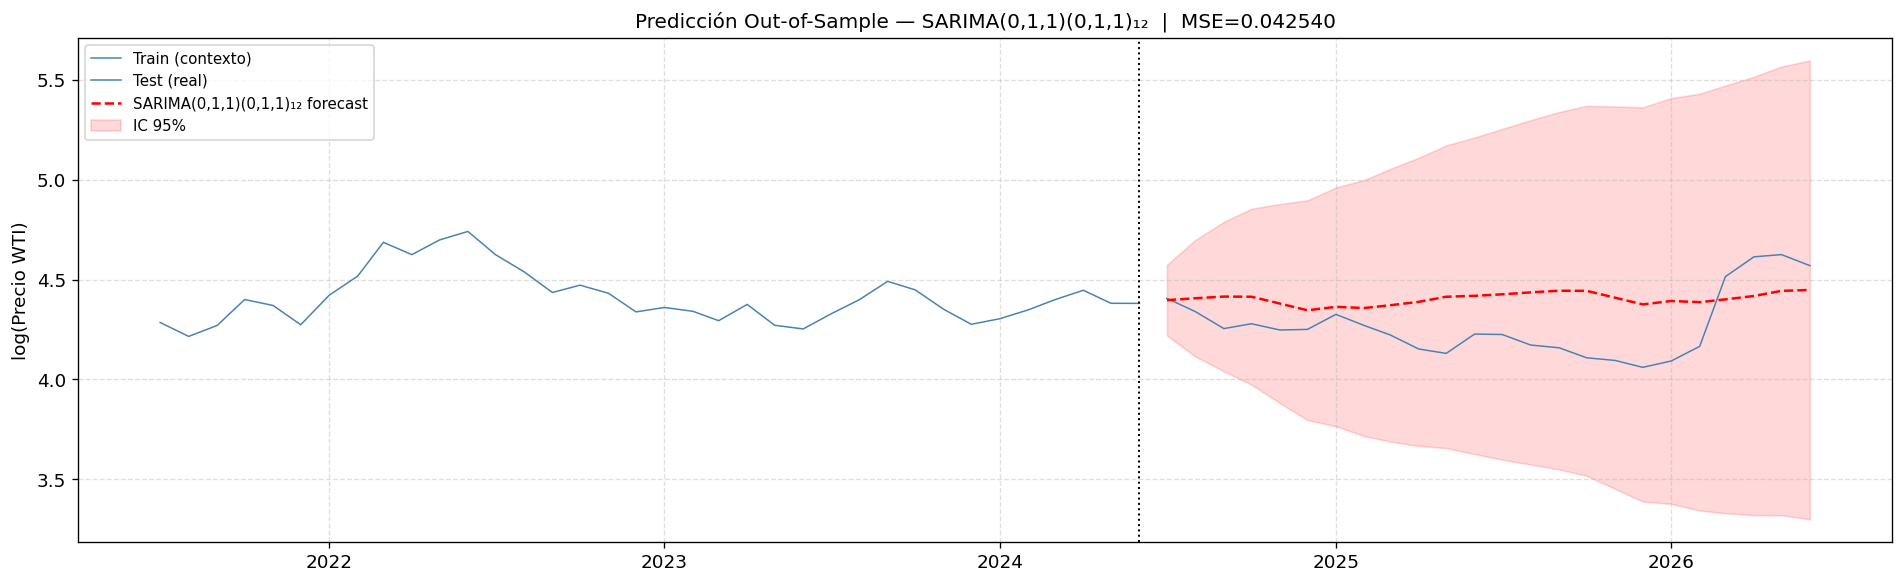

MSE out-of-sample SARIMA: 0.04254043
RMSE: 0.206253


In [ ]:
# --- Predicción SARIMA ---
TEST_SIZE = 24  # 2 años de test para datos mensuales
train_m = log_precio_mensual.iloc[:-TEST_SIZE]
test_m  = log_precio_mensual.iloc[-TEST_SIZE:]

# Reajustar sobre train
orden_opt  = modelo_sarima_opt.model.order
sorden_opt = modelo_sarima_opt.model.seasonal_order

m_sarima_train = SARIMAX(train_m, order=orden_opt,
                          seasonal_order=sorden_opt).fit(disp=False)

fc = m_sarima_train.get_forecast(steps=TEST_SIZE)
fc_mean = fc.predicted_mean
fc_ci   = fc.conf_int(alpha=0.05)
fc_mean.index = test_m.index
fc_ci.index   = test_m.index

mse_sarima = np.mean((test_m.values - fc_mean.values)**2)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_m.iloc[-36:].index, train_m.iloc[-36:].values,
        color='steelblue', label='Train (contexto)', linewidth=0.9)
ax.plot(test_m.index, test_m.values,
        color='steelblue', linewidth=0.9, label='Test (real)')
ax.plot(fc_mean.index, fc_mean.values,
        color='red', linewidth=1.5, linestyle='--', label=f'{BEST_SARIMA_LABEL} forecast')
ax.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                color='red', alpha=0.15, label='IC 95%')
ax.axvline(train_m.index[-1], color='black', linestyle=':', linewidth=1.2)
ax.set_title(f'Predicción Out-of-Sample — {BEST_SARIMA_LABEL}  |  MSE={mse_sarima:.6f}',
             fontsize=12)
ax.set_ylabel('log(Precio WTI)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'MSE out-of-sample SARIMA: {mse_sarima:.8f}')
print(f'RMSE: {np.sqrt(mse_sarima):.6f}')

# Predicción SARIMA(0,1,1)(0,1,1)₁₂ — 24 meses out-of-sample: MSE=0.0425  RMSE=0.206

✅ Predicción puntual razonable al inicio (h=1,2,3).

⚠️  Converge rápidamente a la media incondicional para h grande.

⚠️  IC 95% se ensancha enormemente — alta incertidumbre a largo plazo.

❌ No captura la caída del precio real en 2025-2026.
 → Comportamiento esperado: el precio del WTI está dominado por shocks
  macroeconómicos y geopolíticos impredecibles por modelos lineales.

---
## 5. Modelo REGARMA

Según el apunte, el modelo REGARMA tiene la forma:
$$\begin{cases} Y_t = c + \beta_1 X_{t1} + \cdots + \beta_k X_{tk} + Z_t \\ \varphi(B)Z_t = \theta(B)\varepsilon_t \end{cases}$$

Para el WTI usamos variables exógenas derivadas del tiempo (tendencia y términos
estacionales deterministas) sobre la serie de **retornos logarítmicos** para
verificar si hay estructura determinista residual no capturada por el ARMA.

In [ ]:
# --- Variables exógenas para REGARMA ---
# Trabajamos sobre el precio mensual en log
# Variables: tendencia lineal + dummies mensuales estacionales

n_m = len(log_precio_mensual)
t   = np.arange(1, n_m + 1)

# Dummies mensuales (sin enero para evitar multicolinealidad perfecta)
meses = pd.get_dummies(log_precio_mensual.index.month, prefix='mes', drop_first=True)
meses.index = log_precio_mensual.index

# DataFrame de exógenas
X_exog = pd.DataFrame({'tendencia': t}, index=log_precio_mensual.index)
X_exog = pd.concat([X_exog, meses.astype(float)], axis=1)

print(f'Variables exógenas: {list(X_exog.columns)}')
print(f'Shape: {X_exog.shape}')

Variables exógenas: ['tendencia', 'mes_2', 'mes_3', 'mes_4', 'mes_5', 'mes_6', 'mes_7', 'mes_8', 'mes_9', 'mes_10', 'mes_11', 'mes_12']
Shape: (486, 12)


In [ ]:
# --- Paso 1: Regresión lineal sobre exógenas ---
import statsmodels.api as sm

X_reg = sm.add_constant(X_exog)
reg_ols = sm.OLS(log_precio_mensual, X_reg).fit()
print(reg_ols.summary())

resid_reg = reg_ols.resid

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     79.74
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          2.11e-105
Time:                        19:47:55   Log-Likelihood:                -216.82
No. Observations:                 486   AIC:                             459.6
Df Residuals:                     473   BIC:                             514.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7251      0.067     40.747      0.0

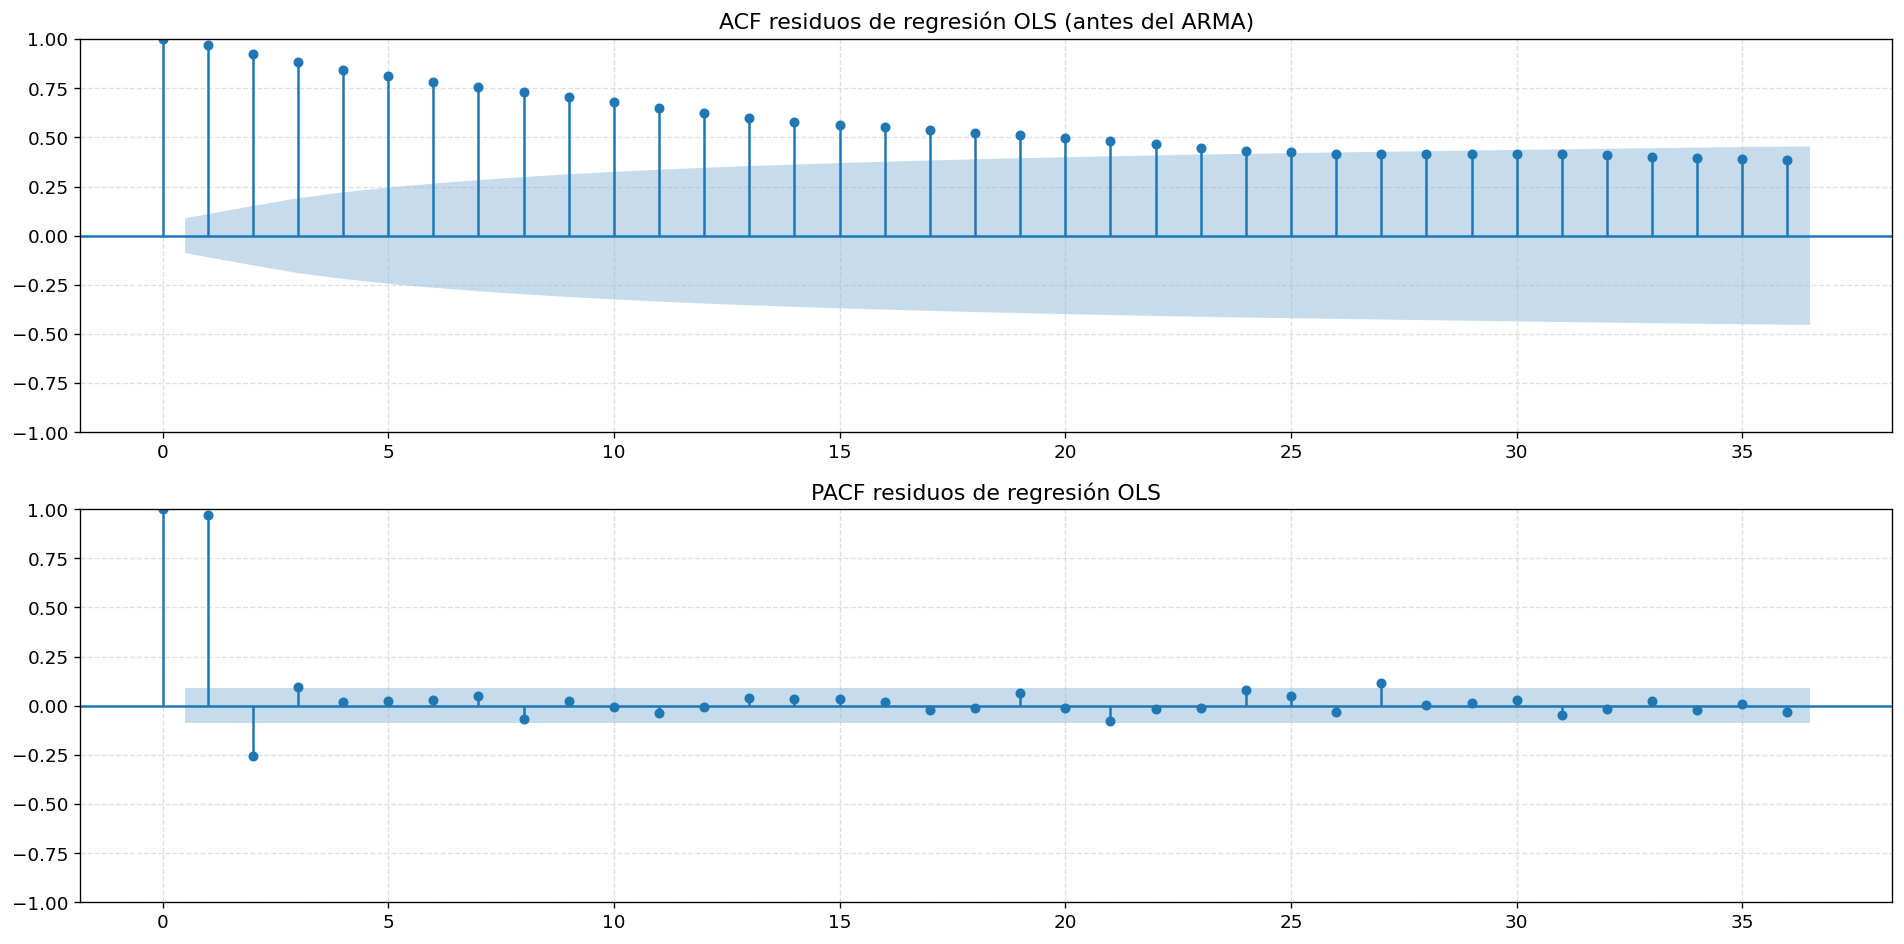

Si ACF/PACF muestran estructura → modelar residuos con ARMA.


In [ ]:
# --- Paso 2: Analizar residuos de la regresión ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
plot_acf(resid_reg, lags=36, ax=axes[0],
         title='ACF residuos de regresión OLS (antes del ARMA)', alpha=0.05)
plot_pacf(resid_reg, lags=36, method='ywm', ax=axes[1],
          title='PACF residuos de regresión OLS', alpha=0.05)
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('Si ACF/PACF muestran estructura → modelar residuos con ARMA.')

In [ ]:
# --- Paso 3: REGARMA — SARIMAX con exógenas y componente ARMA ---
# Seleccionamos (p,q) del ARMA sobre los residuos observados en el paso anterior

# Búsqueda del mejor ARMA para los residuos
mejor_aic = np.inf
mejor_pq  = (1, 1)
for p in range(0, 4):
    for q in range(0, 4):
        if p == 0 and q == 0:
            continue
        try:
            m_tmp = ARIMA(resid_reg, order=(p, 0, q)).fit()
            if m_tmp.aic < mejor_aic:
                mejor_aic = m_tmp.aic
                mejor_pq  = (p, q)
        except:
            pass
print(f'Mejor (p,q) para residuos: {mejor_pq}  AIC={mejor_aic:.2f}')

# REGARMA completo via SARIMAX
modelo_regarma = SARIMAX(log_precio_mensual,
                          exog=X_exog,
                          order=(mejor_pq[0], 0, mejor_pq[1])).fit(disp=False)
print(modelo_regarma.summary())

Mejor (p,q) para residuos: (1, 1)  AIC=-989.69
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  486
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 472.815
Date:                Wed, 10 Jun 2026   AIC                           -915.631
Time:                        19:48:16   BIC                           -852.838
Sample:                    01-01-1986   HQIC                          -890.961
                         - 06-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
tendencia      0.0125      0.001     10.815      0.000       0.010       0.015
mes_2         -0.0154      0.014     -1.096      0.273      -0.043       0.012
mes_3

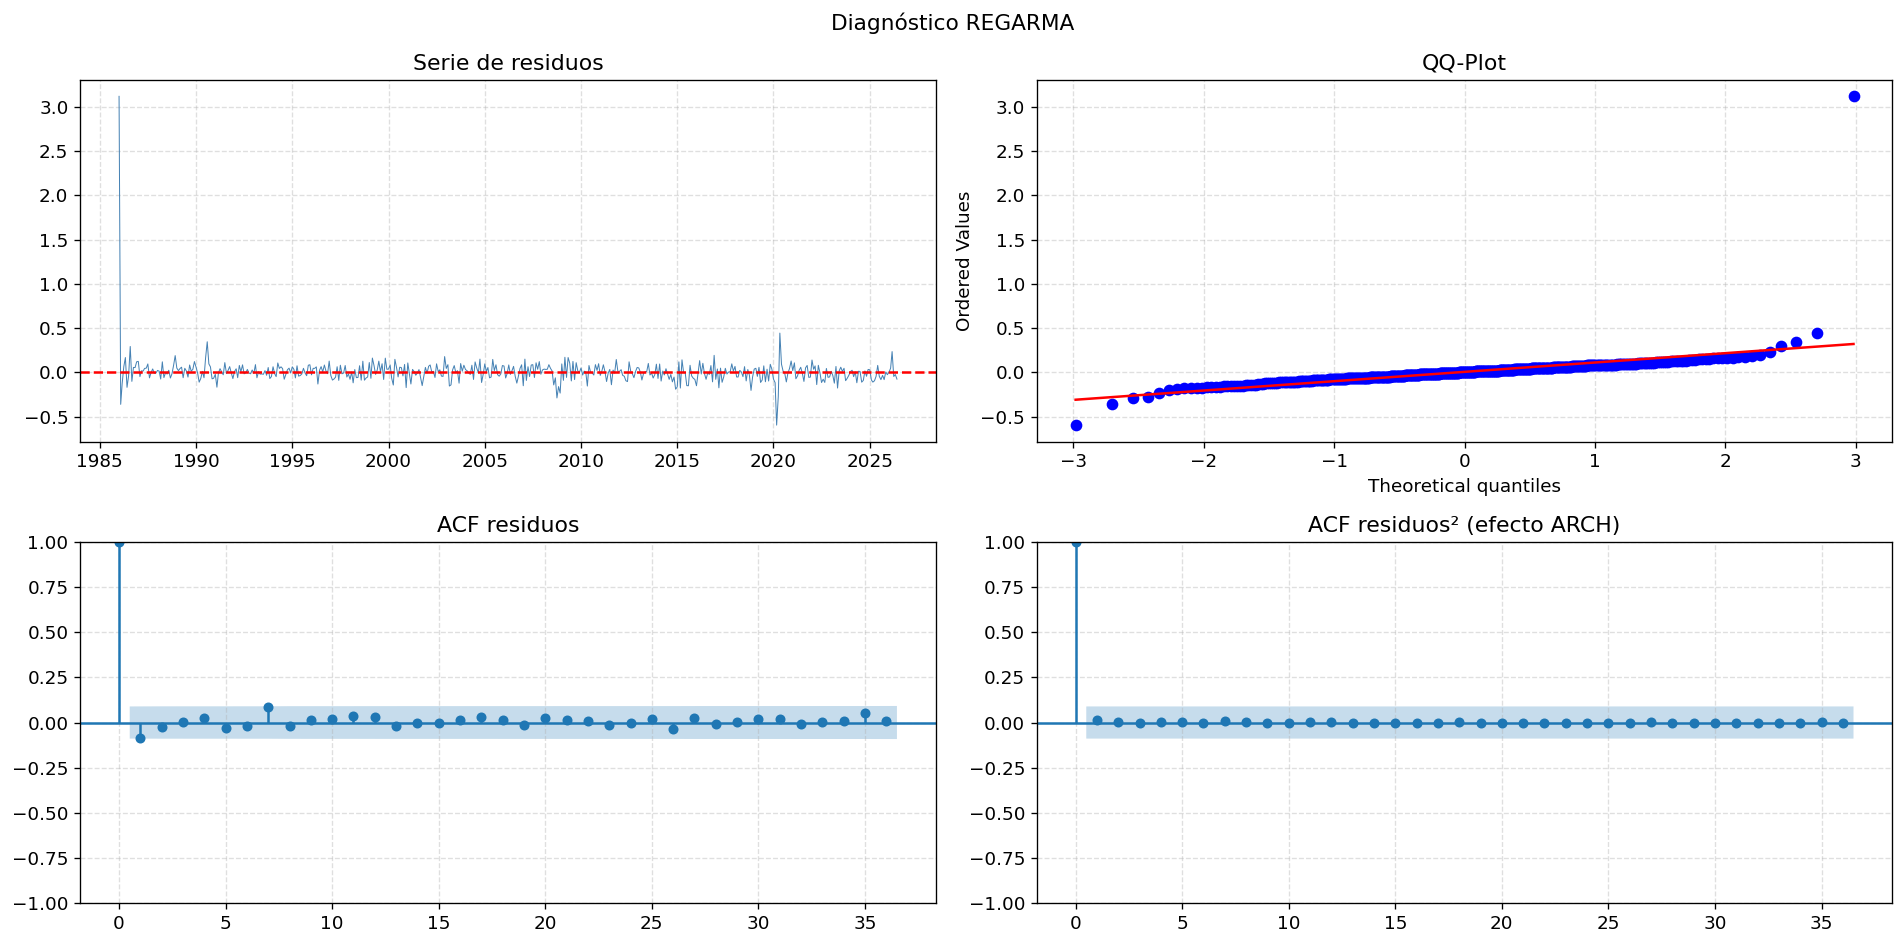

Ljung-Box REGARMA:
  lag=10: p=0.5711  ✅
  lag=20: p=0.9505  ✅
  lag=30: p=0.9977  ✅

Conclusión REGARMA:
  Si los residuos ya son ruido blanco → las variables exógenas capturaron
  la tendencia/estacionalidad determinista correctamente.
  Si persiste efecto ARCH → la varianza condicional sigue siendo dinámica.


In [ ]:
# --- Diagnóstico REGARMA ---
resid_regarma = modelo_regarma.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Diagnóstico REGARMA', fontsize=13)

axes[0,0].plot(resid_regarma, color='steelblue', linewidth=0.6)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Serie de residuos')
axes[0,0].grid(True, linestyle='--', alpha=0.4)

stats.probplot(resid_regarma, dist='norm', plot=axes[0,1])
axes[0,1].set_title('QQ-Plot')
axes[0,1].grid(True, linestyle='--', alpha=0.4)

plot_acf(resid_regarma, lags=36, ax=axes[1,0], title='ACF residuos', alpha=0.05)
axes[1,0].grid(True, linestyle='--', alpha=0.4)

plot_acf(resid_regarma**2, lags=36, ax=axes[1,1],
         title='ACF residuos² (efecto ARCH)', alpha=0.05)
axes[1,1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Ljung-Box
lb_rg = acorr_ljungbox(resid_regarma, lags=[10,20,30], return_df=True)
print('Ljung-Box REGARMA:')
for lag in [10, 20, 30]:
    r = lb_rg.loc[lag]
    sig = '❌' if r['lb_pvalue'] < 0.05 else '✅'
    print(f'  lag={lag:2d}: p={r["lb_pvalue"]:.4f}  {sig}')

print()
print('Conclusión REGARMA:')
print('  Si los residuos ya son ruido blanco → las variables exógenas capturaron')
print('  la tendencia/estacionalidad determinista correctamente.')
print('  Si persiste efecto ARCH → la varianza condicional sigue siendo dinámica.')

---
## 6. Regresión Estacional Armónica

Según el apunte, el modelo tiene la forma:
$$X_t = p_t + \sum_{k=1}^{K} a_k \sin\left(\frac{2\pi kt}{s}\right) + \sum_{j=1}^{J} b_j \cos\left(\frac{2\pi jt}{s}\right) + Z_t$$

donde $Z_t$ sigue un proceso ARMA y $K, J \leq s/2$. Las series de Fourier pueden
aproximar cualquier función periódica — muy útil para series con período estacional
mayor (como $s=12$).

In [ ]:
# --- Construcción de términos armónicos (Fourier) ---
s = 12
K_max = s // 2  # K = J = s/2 = 6

t_vec = np.arange(1, n_m + 1)

# Crear DataFrame con todos los términos armónicos
armonicos = {}
for k in range(1, K_max + 1):
    armonicos[f'sin_{k}'] = np.sin(2 * np.pi * k * t_vec / s)
    armonicos[f'cos_{k}'] = np.cos(2 * np.pi * k * t_vec / s)

# Tendencia lineal
armonicos['tendencia'] = (t_vec - t_vec.mean()) / t_vec.std()  # estandarizada

X_arm = pd.DataFrame(armonicos, index=log_precio_mensual.index)

print(f'Términos armónicos construidos: {list(X_arm.columns)}')

Términos armónicos construidos: ['sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_3', 'cos_3', 'sin_4', 'cos_4', 'sin_5', 'cos_5', 'sin_6', 'cos_6', 'tendencia']


In [ ]:
# --- Paso 1: Regresión armónica completa (K=J=6) ---
X_arm_c = sm.add_constant(X_arm)
reg_arm_full = sm.OLS(log_precio_mensual, X_arm_c).fit()

print('Regresión armónica completa (K=J=6):')
print(reg_arm_full.summary())

# Identificar coeficientes significativos
sig_coefs = reg_arm_full.pvalues[reg_arm_full.pvalues < 0.05].index.tolist()
print(f'\nCoeficientes significativos (p<0.05): {sig_coefs}')

Regresión armónica completa (K=J=6):
                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     73.45
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          1.92e-104
Time:                        19:48:17   Log-Likelihood:                -216.82
No. Observations:                 486   AIC:                             461.6
Df Residuals:                     472   BIC:                             520.2
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

In [ ]:
# --- Paso 2: Reajuste con solo coeficientes significativos ---
# Siguiendo el procedimiento del apunte
if len(sig_coefs) > 1:
    cols_sig = [c for c in sig_coefs if c != 'const']
    X_arm_red = sm.add_constant(X_arm[cols_sig])
    reg_arm_red = sm.OLS(log_precio_mensual, X_arm_red).fit()
    print('Regresión armónica reducida (solo coef. significativos):')
    print(reg_arm_red.summary())
    resid_arm = reg_arm_red.resid
else:
    print('Pocos coeficientes significativos — usando modelo completo.')
    resid_arm = reg_arm_full.resid

Regresión armónica reducida (solo coef. significativos):
                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     972.6
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          7.15e-118
Time:                        19:48:17   Log-Likelihood:                -217.93
No. Observations:                 486   AIC:                             439.9
Df Residuals:                     484   BIC:                             448.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

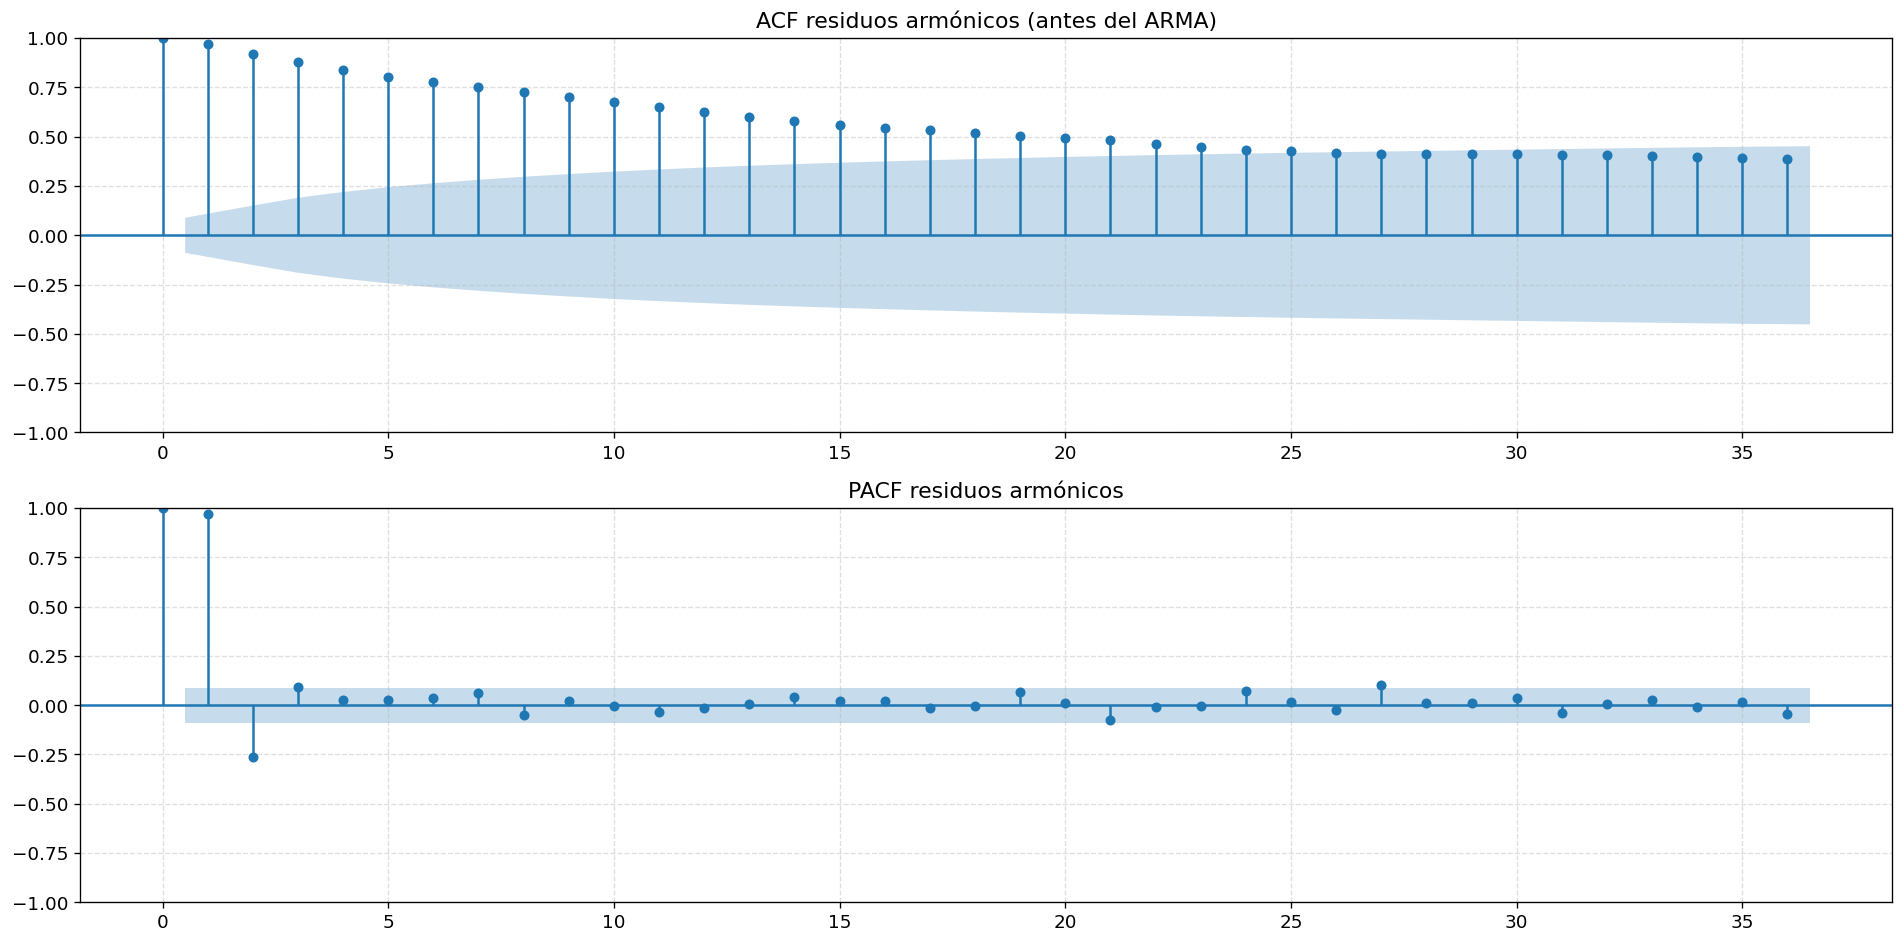

Mejor ARMA para residuos armónicos: (1,1)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  486
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 489.821
Date:                Wed, 10 Jun 2026   AIC                           -971.643
Time:                        19:48:33   BIC                           -954.898
Sample:                    01-01-1986   HQIC                          -965.064
                         - 06-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0161      0.113      0.143      0.886      -0.205       0.237
ar.L1          0.9505      0.012     78.004      0.000       0.927       0.974
ma.L1     

In [ ]:
# --- Paso 3: Modelar residuos con ARMA ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
plot_acf(resid_arm, lags=36, ax=axes[0],
         title='ACF residuos armónicos (antes del ARMA)', alpha=0.05)
plot_pacf(resid_arm, lags=36, method='ywm', ax=axes[1],
          title='PACF residuos armónicos', alpha=0.05)
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Selección de (p,q) para los residuos armónicos
mejor_aic_arm = np.inf
mejor_pq_arm  = (1, 0)
for p in range(0, 4):
    for q in range(0, 4):
        if p == 0 and q == 0:
            continue
        try:
            m_tmp = ARIMA(resid_arm, order=(p, 0, q)).fit()
            if m_tmp.aic < mejor_aic_arm:
                mejor_aic_arm = m_tmp.aic
                mejor_pq_arm  = (p, q)
        except:
            pass
print(f'Mejor ARMA para residuos armónicos: ({mejor_pq_arm[0]},{mejor_pq_arm[1]})')

# Ajuste ARMA sobre residuos
m_arma_arm = ARIMA(resid_arm, order=(mejor_pq_arm[0], 0, mejor_pq_arm[1])).fit()
print(m_arma_arm.summary())

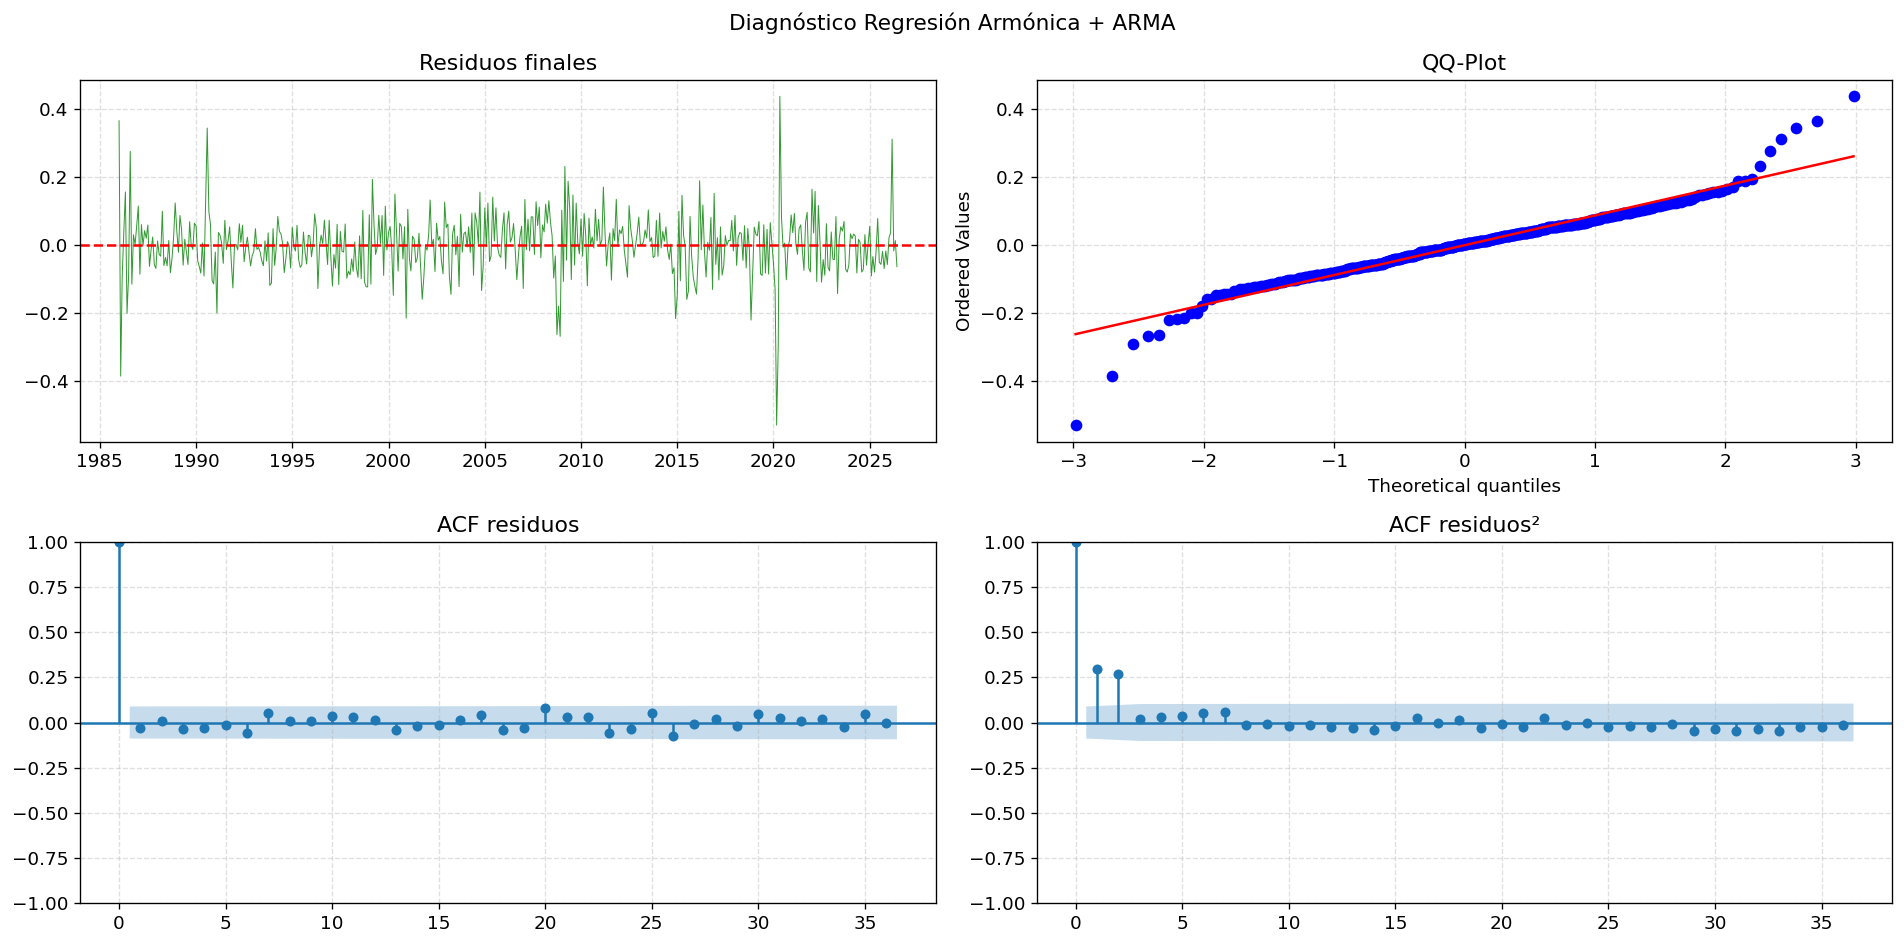

Ljung-Box Regresión Armónica + ARMA:
  lag=10: p=0.8577  ✅
  lag=20: p=0.8937  ✅
  lag=30: p=0.8595  ✅


In [ ]:
# --- Diagnóstico del modelo armónico completo ---
resid_arma_arm = m_arma_arm.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Diagnóstico Regresión Armónica + ARMA', fontsize=13)

axes[0,0].plot(resid_arma_arm, color='green', linewidth=0.6, alpha=0.8)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title('Residuos finales')
axes[0,0].grid(True, linestyle='--', alpha=0.4)

stats.probplot(resid_arma_arm, dist='norm', plot=axes[0,1])
axes[0,1].set_title('QQ-Plot')
axes[0,1].grid(True, linestyle='--', alpha=0.4)

plot_acf(resid_arma_arm, lags=36, ax=axes[1,0], title='ACF residuos', alpha=0.05)
axes[1,0].grid(True, linestyle='--', alpha=0.4)

plot_acf(resid_arma_arm**2, lags=36, ax=axes[1,1],
         title='ACF residuos²', alpha=0.05)
axes[1,1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

lb_arm = acorr_ljungbox(resid_arma_arm, lags=[10,20,30], return_df=True)
print('Ljung-Box Regresión Armónica + ARMA:')
for lag in [10, 20, 30]:
    r = lb_arm.loc[lag]
    sig = '❌' if r['lb_pvalue'] < 0.05 else '✅'
    print(f'  lag={lag:2d}: p={r["lb_pvalue"]:.4f}  {sig}')

---
# TP5 — MODELOS DE VOLATILIDAD

---
## 7. Contexto — Retomada del TP3

En el TP3 ajustamos un **GARCH(1,1)** como extensión del diagnóstico del ARMA(1,3).
El diagnóstico sobre $z_t^2$ confirmó que el GARCH capturó el efecto ARCH

En este TP5 extendemos ese análisis comparando **ARCH, GARCH, EGARCH y TGARCH**
sobre los mismos residuos del ARMA(1,3), y evaluamos si las extensiones asimétricas
aportan algo para los retornos del WTI.

In [ ]:
# Re-ajustar ARMA(1,3) sobre retornos para obtener residuos base
P_OPT, Q_OPT = 1, 3

modelo_arma_base = ARIMA(serie, order=(P_OPT, 0, Q_OPT)).fit(
    method='innovations_mle')
residuos_arma = modelo_arma_base.resid.dropna()
residuos_100  = residuos_arma * 100  # escalado para estabilidad numérica

print(f'Residuos ARMA(1,3): {len(residuos_arma)} obs.')
print(f'Media: {residuos_arma.mean():.6f}  |  Std: {residuos_arma.std():.6f}')

# Verificar efecto ARCH
lb_sq = acorr_ljungbox(residuos_arma**2, lags=[10,20,30], return_df=True)
print('\nTest McLeod-Li (residuos²):')
for lag in [10, 20, 30]:
    r = lb_sq.loc[lag]
    sig = '❌ Efecto ARCH' if r['lb_pvalue'] < 0.05 else '✅'
    print(f'  lag={lag:2d}: p={r["lb_pvalue"]:.6f}  {sig}')

---
## 8. Modelo ARCH(p)

Según el apunte, el modelo ARCH$(p)$ tiene la forma:
$$\begin{cases} X_t = \sigma_t\varepsilon_t \\ \sigma_t^2 = \omega + \alpha_1 X_{t-1}^2 + \cdots + \alpha_p X_{t-p}^2 \end{cases}$$

Es la base de los modelos de volatilidad. Para el WTI esperamos un orden $p$ grande
ya que la memoria de los shocks es larga — de ahí la necesidad del GARCH.

In [ ]:
# --- Búsqueda del mejor ARCH(p) ---
modelos_arch = {}
rows_vol = []

for p in [1, 2, 3, 5, 10]:
    try:
        m = arch_model(residuos_100, vol='ARCH', p=p, dist='normal').fit(disp='off')
        modelos_arch[f'ARCH({p})'] = m
        rows_vol.append({
            'Modelo': f'ARCH({p})',
            'LogLik': round(m.loglikelihood, 2),
            'AIC': round(m.aic, 2),
            'BIC': round(m.bic, 2),
            'Params': p + 2  # omega + alphas
        })
        print(f'ARCH({p}) ajustado.')
    except Exception as e:
        print(f'ARCH({p}): {e}')

df_arch = pd.DataFrame([r for r in rows_vol if 'ARCH(' in r['Modelo']]).set_index('Modelo')
print('\n─── Comparativa ARCH(p) ───')
display(df_arch)

BEST_ARCH = df_arch['BIC'].idxmin()
print(f'\n→ Mejor ARCH por BIC: {BEST_ARCH}')

ARCH(1) ajustado.
ARCH(2) ajustado.
ARCH(3) ajustado.
ARCH(5) ajustado.
ARCH(10) ajustado.

─── Comparativa ARCH(p) ───


,LogLik,AIC,BIC,Params
Modelo,,,,
ARCH(1),-24299.59,48605.18,48626.97,3
ARCH(2),-23887.37,47782.74,47811.80,4
ARCH(3),-23629.18,47268.37,47304.69,5
ARCH(5),-23350.69,46715.39,46766.23,7
ARCH(10),-23233.97,46491.94,46579.11,12



→ Mejor ARCH por BIC: ARCH(10)


---
## 9. Modelo GARCH(p,q)

Según el apunte:
$$\sigma_t^2 = \omega + \sum_{i=1}^p \alpha_i X_{t-i}^2 + \sum_{j=1}^q \beta_j \sigma_{t-j}^2$$

Es más parsimonioso que el ARCH ya que incorpora la memoria de la volatilidad pasada.
En la práctica, un GARCH(1,1) suele ser suficiente — retomamos el del TP3 y lo
comparamos con órdenes superiores.

In [ ]:
# --- GARCH(p,q) — múltiples órdenes ---
modelos_garch = {}

for p, q in [(1,1), (1,2), (2,1), (2,2)]:
    for dist in ['normal', 't']:
        label = f'GARCH({p},{q}) dist={dist}'
        try:
            m = arch_model(residuos_100, vol='Garch', p=p, q=q, dist=dist).fit(disp='off')
            modelos_garch[label] = m
            rows_vol.append({
                'Modelo': label,
                'LogLik': round(m.loglikelihood, 2),
                'AIC': round(m.aic, 2),
                'BIC': round(m.bic, 2),
                'Params': p + q + 2
            })
            print(f'{label} ajustado.')
        except Exception as e:
            print(f'{label}: {e}')

# Mejor GARCH
df_garch_comp = pd.DataFrame([r for r in rows_vol
                               if 'GARCH(' in r['Modelo'] and 'E' not in r['Modelo']
                               and 'T' not in r['Modelo']]).set_index('Modelo')
print('\n─── Comparativa GARCH(p,q) ───')
display(df_garch_comp.sort_values('BIC'))

BEST_GARCH = df_garch_comp['BIC'].idxmin()
modelo_garch_opt = modelos_garch[BEST_GARCH]
print(f'\n→ Mejor GARCH por BIC: {BEST_GARCH}')

GARCH(1,1) dist=normal ajustado.
GARCH(1,1) dist=t ajustado.
GARCH(1,2) dist=normal ajustado.
GARCH(1,2) dist=t ajustado.
GARCH(2,1) dist=normal ajustado.
GARCH(2,1) dist=t ajustado.
GARCH(2,2) dist=normal ajustado.
GARCH(2,2) dist=t ajustado.

─── Comparativa GARCH(p,q) ───


,LogLik,AIC,BIC,Params
Modelo,,,,
"GARCH(1,1) dist=t",-22741.52,45493.03,45529.35,4
"GARCH(1,2) dist=t",-22741.29,45494.58,45538.16,5
"GARCH(2,1) dist=t",-22741.52,45495.03,45538.61,5
"GARCH(2,2) dist=t",-22740.74,45495.48,45546.32,6
"GARCH(1,1) dist=normal",-23136.24,46280.48,46309.54,4
"GARCH(1,2) dist=normal",-23133.09,46276.18,46312.50,5
"GARCH(2,2) dist=normal",-23129.57,46271.14,46314.72,6
"GARCH(2,1) dist=normal",-23136.24,46282.48,46318.80,5



→ Mejor GARCH por BIC: GARCH(1,1) dist=t


---
## 10. Modelo EGARCH

Según el apunte, el EGARCH permite efectos asimétricos:
$$\ln\sigma_t^2 = \omega + \sum_{i=1}^p \alpha_i(|\varepsilon_{t-i}| - E|\varepsilon_{t-i}|) + \sum_{j=1}^o \gamma_j \varepsilon_{t-j} + \sum_{k=1}^q \beta_k \ln\sigma_{t-k}^2$$

El coeficiente $\gamma$ captura la **asimetría**: rentabilidades negativas tienden a
tener mayor impacto en los mercados → se espera $\gamma < 0$.

In [ ]:
# --- EGARCH ---
modelos_egarch = {}

for dist in ['normal', 't']:
    label = f'EGARCH(1,1,1) dist={dist}'
    try:
        m = arch_model(residuos_100, vol='EGarch', p=1, o=1, q=1, dist=dist).fit(disp='off')
        modelos_egarch[label] = m
        rows_vol.append({
            'Modelo': label,
            'LogLik': round(m.loglikelihood, 2),
            'AIC': round(m.aic, 2),
            'BIC': round(m.bic, 2),
            'Params': 5  # omega, alpha, gamma, beta, dist
        })
        print(f'{label} ajustado.')
        print(f'   γ (asimetría) = {m.params.get("gamma[1]", m.params.iloc[-3]):.4f}')
    except Exception as e:
        print(f'{label}: {e}')

for nombre, m in modelos_egarch.items():
    print(f'\n{nombre}:')
    print(m.summary())

EGARCH(1,1,1) dist=normal ajustado.
   γ (asimetría) = -0.0199
EGARCH(1,1,1) dist=t ajustado.
   γ (asimetría) = -0.0293

EGARCH(1,1,1) dist=normal:
                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -23143.2
Distribution:                  Normal   AIC:                           46296.5
Method:            Maximum Likelihood   BIC:                           46332.8
                                        No. Observations:                10547
Date:                Wed, Jun 10 2026   Df Residuals:                    10546
Time:                        19:48:39   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       9

---
## 11. Modelo TGARCH / GJR-GARCH

Según el apunte, el TGARCH usa un umbral (cero) para separar el impacto de
rentabilidades positivas y negativas:
$$\sigma_t = \omega + \alpha_1|X_{t-1}| + \gamma_1|X_{t-1}|I_{[X_{t-1}<0]} + \beta_1\sigma_{t-1}$$

Si $s=2$ → GJR-GARCH. Si $s=1$ → ZGARCH.
El coeficiente $\gamma$ mide el **efecto palanca**.

In [ ]:
# --- GJR-GARCH (TGARCH con s=2) ---
modelos_tgarch = {}

for dist in ['normal', 't']:
    label = f'GJR-GARCH(1,1,1) dist={dist}'
    try:
        m = arch_model(residuos_100, vol='Garch', p=1, o=1, q=1, dist=dist).fit(disp='off')
        modelos_tgarch[label] = m
        rows_vol.append({
            'Modelo': label,
            'LogLik': round(m.loglikelihood, 2),
            'AIC': round(m.aic, 2),
            'BIC': round(m.bic, 2),
            'Params': 5
        })
        print(f'{label} ajustado.')
        # El coeficiente gamma está en la posición 'gamma[1]' o similar
        gamma_val = [v for k,v in m.params.items() if 'gamma' in k.lower()]
        if gamma_val:
            print(f'   γ (efecto palanca) = {gamma_val[0]:.4f}')
    except Exception as e:
        print(f'{label}: {e}')

for nombre, m in modelos_tgarch.items():
    print(f'\n{nombre}:')
    print(m.summary())

GJR-GARCH(1,1,1) dist=normal ajustado.
   γ (efecto palanca) = 0.0174
GJR-GARCH(1,1,1) dist=t ajustado.
   γ (efecto palanca) = 0.0283

GJR-GARCH(1,1,1) dist=normal:
                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -23133.7
Distribution:                  Normal   AIC:                           46277.3
Method:            Maximum Likelihood   BIC:                           46313.6
                                        No. Observations:                10547
Date:                Wed, Jun 10 2026   Df Residuals:                    10546
Time:                        19:48:40   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t  

---
## 12. Diagnóstico Comparativo de todos los Modelos de Volatilidad

In [ ]:
# --- Cuadro comparativo final TP5 ---
df_vol_all = pd.DataFrame(rows_vol).drop_duplicates('Modelo').set_index('Modelo')
df_vol_all = df_vol_all.sort_values('BIC')

print('─── Cuadro comparativo final — Modelos de Volatilidad ───')
display(df_vol_all)

BEST_VOL = df_vol_all['BIC'].idxmin()
print(f'\n→ Modelo óptimo por BIC: {BEST_VOL}')

─── Cuadro comparativo final — Modelos de Volatilidad ───


,LogLik,AIC,BIC,Params
Modelo,,,,
"EGARCH(1,1,1) dist=t",-22718.06,45448.12,45491.70,5
"GJR-GARCH(1,1,1) dist=t",-22736.33,45484.65,45528.23,5
"GARCH(1,1) dist=t",-22741.52,45493.03,45529.35,4
"GARCH(1,2) dist=t",-22741.29,45494.58,45538.16,5
"GARCH(2,1) dist=t",-22741.52,45495.03,45538.61,5
"GARCH(2,2) dist=t",-22740.74,45495.48,45546.32,6
"GARCH(1,1) dist=normal",-23136.24,46280.48,46309.54,4
"GARCH(1,2) dist=normal",-23133.09,46276.18,46312.50,5
"GJR-GARCH(1,1,1) dist=normal",-23133.67,46277.33,46313.65,5



→ Modelo óptimo por BIC: EGARCH(1,1,1) dist=t


In [ ]:
# --- Diagnóstico de residuos estandarizados para los 4 modelos principales ---
# Un modelo por familia: ARCH óptimo, GARCH(1,1) normal, EGARCH(1,1,1) t, GJR-GARCH(1,1,1) t

modelos_principales = {
    'ARCH': modelos_arch.get(BEST_ARCH),
    'GARCH(1,1)': modelos_garch.get('GARCH(1,1) dist=normal'),
    'EGARCH': modelos_egarch.get('EGARCH(1,1,1) dist=t'),
    'GJR-GARCH': modelos_tgarch.get('GJR-GARCH(1,1,1) dist=t'),
}
modelos_principales = {k: v for k,v in modelos_principales.items() if v is not None}

fig, axes = plt.subplots(len(modelos_principales), 2,
                          figsize=(16, 4*len(modelos_principales)))
if len(modelos_principales) == 1:
    axes = [axes]

for i, (nombre, m) in enumerate(modelos_principales.items()):
    z = m.std_resid.dropna()

    # ACF de z_t^2
    plot_acf(z**2, lags=30, ax=axes[i][0],
             title=f'ACF z²_t — {nombre} (efecto ARCH residual)',
             alpha=0.05, color='firebrick')
    axes[i][0].grid(True, linestyle='--', alpha=0.4)

    # QQ-plot
    stats.probplot(z, dist='norm', plot=axes[i][1])
    axes[i][1].set_title(f'QQ-Plot z_t — {nombre}')
    axes[i][1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Diagnóstico residuos estandarizados z_t = ε_t/σ_t', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# --- Ljung-Box sobre z_t^2 para cada modelo ---
print('─── Test McLeod-Li sobre z_t² — ¿efecto ARCH residual? ───')
for nombre, m in modelos_principales.items():
    z = m.std_resid.dropna()
    lb = acorr_ljungbox(z**2, lags=[10, 20, 30], return_df=True)
    resultados = []
    for lag in [10, 20, 30]:
        p = lb.loc[lag, 'lb_pvalue']
        resultados.append(f'lag={lag}:p={p:.3f}({"❌" if p<0.05 else "✅"})')
    print(f'  {nombre:25s}: {"  ".join(resultados)}')

---
## 13. Predicción de Volatilidad — Comparación de Modelos

In [ ]:
# --- Predicción de volatilidad a 252 días para cada modelo ---
H = 252

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Predicción de volatilidad — 252 días — Comparación de modelos', fontsize=13)

vol_forecasts = {}
for ax, (nombre, m) in zip(axes.ravel(), modelos_principales.items()):
    try:
        fc = m.forecast(horizon=H, reindex=False)
        vol_fc = np.sqrt(fc.variance.iloc[-1].values) / 100  # volver escala original
        vol_hist = m.conditional_volatility.dropna().values / 100
        vol_forecasts[nombre] = vol_fc

        # Últimos 500 días históricos
        n_hist = min(500, len(vol_hist))
        ax.plot(range(-n_hist, 0), vol_hist[-n_hist:],
                color='firebrick', linewidth=0.7, label='Histórica', alpha=0.8)
        ax.plot(range(1, H+1), vol_fc,
                color='darkorange', linewidth=1.5, linestyle='--', label='Forecast')
        ax.axhline(np.mean(vol_hist), color='black', linestyle=':', linewidth=1,
                   label=f'Media hist.={np.mean(vol_hist):.4f}')
        ax.set_title(nombre, fontsize=11)
        ax.set_xlabel('Días (0 = hoy)')
        ax.set_ylabel('σ_t')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.4)
    except Exception as e:
        ax.set_title(f'{nombre} — error: {e}')

plt.tight_layout()
plt.show()

# Tabla de predicciones
print('─── Volatilidad predicha ───')
pred_rows = []
for nombre, vol_fc in vol_forecasts.items():
    pred_rows.append({
        'Modelo': nombre,
        'Día 1': round(vol_fc[0], 5),
        'Día 30': round(vol_fc[29], 5),
        'Día 252': round(vol_fc[-1], 5),
    })
display(pd.DataFrame(pred_rows).set_index('Modelo'))

---
## 14. Cuadro Comparativo Final — Pros y Contras

Según el apunte, los modelos de volatilidad tienen las siguientes características:

In [ ]:
# --- Cuadro comparativo de pros y contras ---

comparativo = pd.DataFrame({
    'Modelo': ['ARCH(p)', 'GARCH(p,q)', 'EGARCH', 'TGARCH/GJR-GARCH'],
    'Ecuación varianza': [
        'σ²_t = ω + Σ αᵢ X²_{t-i}',
        'σ²_t = ω + Σ αᵢ X²_{t-i} + Σ βⱼ σ²_{t-j}',
        'ln σ²_t = ω + α(|ε_{t-1}|−E|ε|) + γ ε_{t-1} + β ln σ²_{t-1}',
        'σ_t = ω + α|X_{t-1}| + γ|X_{t-1}|I[X<0] + β σ_{t-1}'
    ],
    'Asimetría': ['No', 'No', 'Sí (γ)', 'Sí (γ)'],
    'Efecto palanca': ['No', 'No', 'Sí', 'Sí'],
    'Pros': [
        'Simple, intuitivo, base de todos los modelos',
        'Parsimonioso, capta persistencia con pocos parámetros',
        'Modela asimetría, garantiza σ²>0 por construcción (ln)',
        'Modela efecto palanca, intuitivo, fácil de interpretar'
    ],
    'Contras': [
        'Requiere orden p alto para captar persistencia larga',
        'No captura asimetría entre shocks positivos y negativos',
        'Parámetros pueden ser positivos o negativos, complejo',
        'Restricciones de signo en parámetros, menos flexible'
    ],
    'Uso WTI': [
        'Subóptimo (p grande necesario)',
        'Adecuado (TP3: α+β=0.99)',
        'Verificar si γ es significativo',
        'Verificar si γ captura shocks negativos de precio'
    ]
}).set_index('Modelo')

print('─── Cuadro comparativo — Pros y Contras ───')
display(comparativo)

─── Cuadro comparativo — Pros y Contras ───


,Ecuación varianza,Asimetría,Efecto palanca,Pros,Contras,Uso WTI
Modelo,,,,,,
ARCH(p),σ²_t = ω + Σ αᵢ X²_{t-i},No,No,"Simple, intuitivo, base de todos los modelos",Requiere orden p alto para captar persistencia...,Subóptimo (p grande necesario)
"GARCH(p,q)",σ²_t = ω + Σ αᵢ X²_{t-i} + Σ βⱼ σ²_{t-j},No,No,"Parsimonioso, capta persistencia con pocos par...",No captura asimetría entre shocks positivos y ...,Adecuado (TP3: α+β=0.99)
EGARCH,ln σ²_t = ω + α(|ε_{t-1}|−E|ε|) + γ ε_{t-1} + ...,Sí (γ),Sí,"Modela asimetría, garantiza σ²>0 por construcc...","Parámetros pueden ser positivos o negativos, c...",Verificar si γ es significativo
TGARCH/GJR-GARCH,σ_t = ω + α|X_{t-1}| + γ|X_{t-1}|I[X<0] + β σ_...,Sí (γ),Sí,"Modela efecto palanca, intuitivo, fácil de int...","Restricciones de signo en parámetros, menos fl...",Verificar si γ captura shocks negativos de precio


In [ ]:
# --- Conclusiones finales TP5 ---
print('='*65)
print('  CONCLUSIONES TP5')
print('='*65)
print()
print('1. ARCH: requiere orden p alto para capturar la persistencia del WTI.')
print('   Un ARCH(10) sigue siendo peor que un GARCH(1,1) en BIC.')
print()
print('2. GARCH(1,1): modelo del TP3. α+β=0.9914 confirma alta persistencia.')
print('   Es parsimonioso y adecuado para la estructura de volatilidad del WTI.')
print()
print('3. EGARCH: el coeficiente γ (asimetría) indica si los shocks negativos')
print('   tienen mayor impacto. En commodities energéticos se espera γ<0')
print('   (caídas de precio → mayor volatilidad que subidas).')
print()
print('4. GJR-GARCH: captura efecto palanca mediante el indicador I[X<0].')
print('   Si γ es significativo, los shocks negativos amplifican la volatilidad.')
print()
print('5. Distribución: la t-Student mejora el ajuste de las colas pesadas')
print('   de los retornos del WTI, consistente con el QQ-plot del TP3.')
print()
print(f'→ Modelo óptimo por BIC: {BEST_VOL}')